# Qwen matched-information direct test

This notebook evaluates the scaled pre-deliberation Qwen comparison under the matched-information framework. It is not a search for an old H1 label: the key questions are whether the activation reader contains target-specific signal, how it compares with shuffled controls, and whether it adds predictive value over the strongest same-information non-activation comparator.

**Repository framing.** The current paper separates target-specific representation from predictive privilege. A positive neural result is interpreted only after behavioural validity, control, comparator-strength, timing, and information-set checks.


# Latent reservations — Notebook 19
## Direct CICERO-style H1: pre-action activation reader vs strong matched exact-text observer

**v3 runtime split:** native Diplomacy reconstruction/adjudication runs only in the already-validated CICERO Python 3.7 + PyTorch 1.7.1 subprocess runtime. Qwen activation capture, text observers, grouped prediction, bootstrap inference, and H1 decisions run in the modern notebook kernel.


In [1]:
NOTEBOOK_BUILD = "latent-reservations-notebook19-cicero-h1-activation-vs-strong-text-v4-streamed-fast-state-selection"
print("=" * 104)
print(f"NOTEBOOK BUILD: {NOTEBOOK_BUILD}")
print("Direct CICERO-style H1: pre-action activation reader vs strong matched exact-text observer")
print("Native pydipcc is isolated in the accepted legacy CICERO subprocess runtime.")
print("=" * 104)


NOTEBOOK BUILD: latent-reservations-notebook19-cicero-h1-activation-vs-strong-text-v4-streamed-fast-state-selection
Direct CICERO-style H1: pre-action activation reader vs strong matched exact-text observer
Native pydipcc is isolated in the accepted legacy CICERO subprocess runtime.


## 1. Dependencies, paths, and isolated outputs

This notebook reuses the current-Python `pydipcc` route validated by Notebook 11 and the locally cached Qwen checkpoint used in the preceding CICERO-style notebooks.

**v2 engine repair:** if the repository-local `pydipcc` extension cannot be imported, this notebook does not try to fix an ABI-incompatible binary by preloading Torch libraries. Instead it uses Notebook 11's isolated Python-3.12 engine environment, performs a clean `make dipcc` rebuild from the frozen CICERO source commit, verifies the rebuilt extension in a fresh subprocess, and only then imports it into the notebook kernel.


In [2]:
from __future__ import annotations

import copy
import gc
import hashlib
import importlib
import itertools
import json
import math
import os
import re
import shutil
import subprocess
import sys
import time
import zipfile
from collections import Counter, defaultdict
from datetime import datetime, timezone
from pathlib import Path

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "numpy<2",
        "pandas>=2,<3",
        "scikit-learn>=1.4,<2",
        "scipy>=1.12,<2",
        "safetensors>=0.4",
        "transformers>=4.45,<5",
        "accelerate>=0.30,<2",
        "tqdm>=4.66",
        "matplotlib>=3.8,<4",
    ],
    check=True,
)

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

PROJECT_ROOT = Path(os.environ.get("LR_PROJECT_ROOT", "/workspace/latent-reservations")).expanduser().resolve()
NOTEBOOK_SLUG = "19_cicero_h1_activation_vs_strong_text"
RUN_ID = os.environ.get("LR_NB19_RUN_ID", datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ"))
BASE = PROJECT_ROOT / "notebook_outputs" / NOTEBOOK_SLUG
RUN_DIR = BASE / RUN_ID
MANIFEST_DIR = RUN_DIR / "manifests"
DATA_DIR = RUN_DIR / "data"
STATE_DIR = DATA_DIR / "states"
ACTIVATION_DIR = DATA_DIR / "activations"
RAW_DIR = DATA_DIR / "raw_outputs"
TABLE_DIR = RUN_DIR / "results" / "tables"
FIGURE_DIR = RUN_DIR / "results" / "figures"
CICERO_REPO = PROJECT_ROOT / "vendor" / "diplomacy_cicero"

HF_CACHE_DIR = Path(
    os.environ.get(
        "LR_NB19_HF_CACHE_DIR",
        os.environ.get("HF_HOME", "/workspace/.cache/huggingface"),
    )
).expanduser().resolve()

for path in [MANIFEST_DIR, STATE_DIR, ACTIVATION_DIR, RAW_DIR, TABLE_DIR, FIGURE_DIR]:
    path.mkdir(parents=True, exist_ok=True)
BASE.mkdir(parents=True, exist_ok=True)
(BASE / "latest_run.json").write_text(json.dumps({
    "notebook_slug": NOTEBOOK_SLUG,
    "run_id": RUN_ID,
    "run_output_dir": str(RUN_DIR),
    "updated_at_utc": datetime.now(timezone.utc).isoformat(),
}, indent=2))

print({
    "project_root": str(PROJECT_ROOT),
    "run_id": RUN_ID,
    "run_dir": str(RUN_DIR),
    "hf_cache_dir": str(HF_CACHE_DIR),
})


{'project_root': '/workspace/latent-reservations', 'run_id': '20260815T180359Z', 'run_dir': '/workspace/latent-reservations/notebook_outputs/19_cicero_h1_activation_vs_strong_text/20260815T180359Z', 'hf_cache_dir': '/workspace/.cache/huggingface'}


## 2. Inherit accepted CICERO provenance and verify/restore the legacy native engine

Notebook 14 established a project-local Python 3.7 runtime with PyTorch 1.7.1+cu110 and a working `pydipcc.cpython-37m...so`. Notebook 19 never imports that extension into the modern kernel.


In [3]:
import json
import os
import shutil
import subprocess
from pathlib import Path

NB10_BASE = PROJECT_ROOT / "notebook_outputs" / "10_cicero_full_press_bootstrap_data_discovery"
NB11_BASE = PROJECT_ROOT / "notebook_outputs" / "11_cicero_native_engine_legal_order_replay"
NB10_RUN_DIR = Path(json.loads((NB10_BASE / "latest_run.json").read_text())["run_output_dir"])
NB11_RUN_DIR = Path(json.loads((NB11_BASE / "latest_run.json").read_text())["run_output_dir"])

nb10_summary = json.loads((NB10_RUN_DIR / "results" / "tables" / "result_summary.json").read_text())
nb11_summary = json.loads((NB11_RUN_DIR / "results" / "tables" / "result_summary.json").read_text())

if not nb10_summary["readiness"]["ready_for_notebook11_engine_integration"]:
    raise RuntimeError("Notebook 10 readiness is not green.")
if not nb11_summary["readiness"]["ready_for_notebook12_full_press_order_pilot"]:
    raise RuntimeError("Notebook 11 readiness is not green.")

CICERO_COMMIT = nb11_summary["cicero_commit"]
actual_commit = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=CICERO_REPO, text=True).strip()
if actual_commit != CICERO_COMMIT:
    subprocess.run(["git", "checkout", "--detach", CICERO_COMMIT], cwd=CICERO_REPO, check=True)

tracked_status = subprocess.check_output(
    ["git", "status", "--porcelain", "--untracked-files=no"],
    cwd=CICERO_REPO,
    text=True,
).strip()
if tracked_status:
    raise RuntimeError("Frozen CICERO checkout contains tracked modifications:\n" + tracked_status)

LEGACY_ENV = PROJECT_ROOT / ".venvs" / "cicero_full_agent_py37_source_v5"
LEGACY_PYTHON = LEGACY_ENV / "bin" / "python"
PYTHON_BASE = PROJECT_ROOT / "vendor" / "cicero_runtime_v5" / "cpython-3.7.17"
ENGINE_DIR = DATA_DIR / "legacy_engine"
ENGINE_DIR.mkdir(parents=True, exist_ok=True)

if not LEGACY_PYTHON.exists():
    raise FileNotFoundError(
        f"Accepted Notebook 14 legacy interpreter is missing: {LEGACY_PYTHON}. "
        "Restore/rerun Notebook 14 rather than compiling pydipcc in the modern kernel."
    )

stack_markers = sorted(LEGACY_ENV.glob(".latent_reservations_cicero_stack_v5_*"))
if not stack_markers:
    raise RuntimeError("Notebook 14 legacy stack marker is missing.")
stack_marker = stack_markers[-1]
stack_meta = json.loads(stack_marker.read_text())
if stack_meta.get("cicero_commit") != CICERO_COMMIT:
    raise RuntimeError("Legacy CICERO stack marker commit does not match the frozen source commit.")

probe_code = r'''
import json, pathlib, sys
import torch, pybind11
root = pathlib.Path(torch.__file__).resolve().parent
print(json.dumps({
    "python": sys.executable,
    "python_version": sys.version,
    "torch": torch.__version__,
    "torch_cmake_prefix": str(torch.utils.cmake_prefix_path),
    "torch_lib": str(root / "lib"),
    "pybind11": pybind11.__version__,
    "pybind11_cmake_dir": pybind11.get_cmake_dir(),
}))
'''
probe = subprocess.run(
    [str(LEGACY_PYTHON), "-c", probe_code],
    cwd=CICERO_REPO,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    check=False,
)
if probe.returncode != 0:
    raise RuntimeError("Legacy Notebook 14 Python/Torch/pybind11 probe failed:\n" + probe.stdout)
legacy_probe = json.loads(probe.stdout.strip().splitlines()[-1])
if not str(legacy_probe["torch"]).startswith("1.7.1"):
    raise RuntimeError(f"Expected legacy PyTorch 1.7.1, got {legacy_probe['torch']}")

legacy_engine_env = os.environ.copy()
for key in ["PYTHONPATH", "PYTHONHOME", "CMAKE_TOOLCHAIN_FILE", "CMAKE_C_COMPILER", "CMAKE_CXX_COMPILER"]:
    legacy_engine_env.pop(key, None)
legacy_engine_env["PATH"] = str(LEGACY_ENV / "bin") + os.pathsep + legacy_engine_env.get("PATH", "")
legacy_engine_env["PYTHON"] = str(LEGACY_PYTHON)
legacy_engine_env["PYTHON_EXECUTABLE"] = str(LEGACY_PYTHON)
legacy_engine_env["VIRTUAL_ENV"] = str(LEGACY_ENV)
legacy_engine_env["PYTHONNOUSERSITE"] = "1"
legacy_engine_env["PYBIND11_CMAKE_DIR"] = str(legacy_probe["pybind11_cmake_dir"])
legacy_engine_env["CMAKE_PREFIX_PATH"] = os.pathsep.join([
    str(legacy_probe["pybind11_cmake_dir"]),
    str(legacy_probe["torch_cmake_prefix"]),
    str(LEGACY_ENV),
    str(PYTHON_BASE),
])
legacy_engine_env["CMAKE_LIBRARY_PATH"] = os.pathsep.join([
    str(legacy_probe["torch_lib"]),
    str(LEGACY_ENV / "lib"),
    str(PYTHON_BASE / "lib"),
])
legacy_engine_env["LD_LIBRARY_PATH"] = os.pathsep.join([
    str(legacy_probe["torch_lib"]),
    str(LEGACY_ENV / "lib"),
    str(PYTHON_BASE / "lib"),
    legacy_engine_env.get("LD_LIBRARY_PATH", ""),
])
if stack_meta.get("cxxflags"):
    legacy_engine_env["CXXFLAGS"] = str(stack_meta["cxxflags"])

legacy_import_code = r'''
import json, sys, torch
from fairdiplomacy import pydipcc
print(json.dumps({
    "python": sys.executable,
    "torch": torch.__version__,
    "pydipcc": pydipcc.__file__,
    "has_game": hasattr(pydipcc, "Game"),
}))
'''

def legacy_import_probe():
    return subprocess.run(
        [str(LEGACY_PYTHON), "-c", legacy_import_code],
        cwd=CICERO_REPO,
        env=legacy_engine_env,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        check=False,
    )

import_probe = legacy_import_probe()
rebuilt = False
if import_probe.returncode != 0:
    print("Legacy pydipcc is missing/broken; restoring it under the accepted Notebook 14 toolchain.")
    print(import_probe.stdout)
    dipcc_build = CICERO_REPO / "dipcc" / "build"
    if dipcc_build.exists():
        shutil.rmtree(dipcc_build)
    build = subprocess.run(
        ["make", "dipcc"],
        cwd=CICERO_REPO,
        env=legacy_engine_env,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        check=False,
    )
    build_log = ENGINE_DIR / "legacy_make_dipcc.log"
    build_log.write_text(build.stdout, encoding="utf-8")
    print("\n".join(build.stdout.splitlines()[-100:]))
    if build.returncode != 0:
        raise RuntimeError(
            f"Legacy Notebook-14-compatible `make dipcc` failed; log: {build_log}\n\n"
            + "\n".join(build.stdout.splitlines()[-120:])
        )
    import_probe = legacy_import_probe()
    rebuilt = True

if import_probe.returncode != 0:
    raise RuntimeError("Legacy pydipcc still cannot import after rebuild.\n" + import_probe.stdout)

legacy_runtime = json.loads(import_probe.stdout.strip().splitlines()[-1])
if not legacy_runtime.get("has_game"):
    raise RuntimeError("Legacy pydipcc imported without Game.")
pydipcc_path = Path(legacy_runtime["pydipcc"]).resolve()
if not pydipcc_path.exists() or pydipcc_path.suffix != ".so":
    raise RuntimeError(f"Legacy pydipcc did not resolve to a compiled extension: {pydipcc_path}")

engine_handoff = {
    "cicero_commit": CICERO_COMMIT,
    "legacy_python": str(LEGACY_PYTHON),
    "legacy_torch": legacy_runtime["torch"],
    "legacy_pydipcc": str(pydipcc_path),
    "rebuilt_in_this_run": rebuilt,
    "modern_kernel_imports_pydipcc": False,
    "stack_marker": str(stack_marker),
}
(MANIFEST_DIR / "legacy_native_engine_handoff.json").write_text(json.dumps(engine_handoff, indent=2))
print(json.dumps(engine_handoff, indent=2))


{
  "cicero_commit": "e85afeddb34f5b7c1ea0827203b425a0f7e68ead",
  "legacy_python": "/workspace/latent-reservations/.venvs/cicero_full_agent_py37_source_v5/bin/python",
  "legacy_torch": "1.7.1+cu110",
  "legacy_pydipcc": "/workspace/latent-reservations/vendor/diplomacy_cicero/fairdiplomacy/pydipcc.cpython-37m-x86_64-linux-gnu.so",
  "rebuilt_in_this_run": false,
  "modern_kernel_imports_pydipcc": false,
  "stack_marker": "/workspace/latent-reservations/.venvs/cicero_full_agent_py37_source_v5/.latent_reservations_cicero_stack_v5_7"
}


## 3. Freeze the H1 protocol before generating any labels

The protocol below is intentionally fixed before Qwen produces a single action.

Key choices:

- target 80 frozen states, at most two per source game;
- require at least 60 usable states and at least 30 source games;
- use the **compact natural-reasoning T0** interface, which was the cleanest valid pre-output condition in Notebook 13;
- no frozen generated deliberation is inserted into the prompt, so the matched observer cannot simply read a previously verbalized commitment;
- 5 outer folds grouped by source game (`game_index % 5`), with inner-fold selection of activation layer/regularization and trained-text regularization;
- the primary strong text comparator is selected **inside each outer training set** between the matched generative observer and the trained exact-prompt text classifier;
- primary uncertainty is a paired source-game cluster bootstrap.


In [4]:
TARGET_STATES = int(os.environ.get("LR_NB19_TARGET_STATES", "80"))
MAX_STATES_PER_GAME = int(os.environ.get("LR_NB19_MAX_STATES_PER_GAME", "2"))
MIN_USABLE_STATES = int(os.environ.get("LR_NB19_MIN_USABLE_STATES", "60"))
MIN_SOURCE_GAMES = int(os.environ.get("LR_NB19_MIN_SOURCE_GAMES", "30"))
MIN_SUBJECT_MESSAGES = int(os.environ.get("LR_NB19_MIN_SUBJECT_MESSAGES", "2"))
MAX_CANDIDATES_PER_GAME = int(os.environ.get("LR_NB19_MAX_CANDIDATES_PER_GAME", "160"))
N_OUTER_FOLDS = 5

ACTION_GENERATION_CEILING = int(os.environ.get("LR_NB19_ACTION_TOKEN_CEILING", "4096"))
AUDITOR_GENERATION_CEILING = int(os.environ.get("LR_NB19_AUDITOR_TOKEN_CEILING", "1024"))
ACTION_VALIDITY_MIN = float(os.environ.get("LR_NB19_ACTION_VALIDITY_MIN", "0.95"))
AUDITOR_VALIDITY_MIN = float(os.environ.get("LR_NB19_AUDITOR_VALIDITY_MIN", "0.95"))
MIN_EACH_LABEL = int(os.environ.get("LR_NB19_MIN_EACH_LABEL", "15"))
BOOTSTRAP_REPS = int(os.environ.get("LR_NB19_BOOTSTRAP_REPS", "20000"))
SEED = int(os.environ.get("LR_SEED", "20260815"))

if MAX_STATES_PER_GAME < 1:
    raise ValueError("MAX_STATES_PER_GAME must be >= 1")
if TARGET_STATES < MIN_USABLE_STATES:
    raise ValueError("TARGET_STATES must be >= MIN_USABLE_STATES")

protocol = {
    "hypothesis": "H1: source-game-held-out Brier(strong matched text) - Brier(activation) > 0",
    "environment": "CICERO-derived full-press Diplomacy released states",
    "subject_model_default": "Qwen/Qwen2.5-7B-Instruct",
    "behavioral_target": "revealed consequential choice of option B versus option A",
    "state_target_count": TARGET_STATES,
    "max_states_per_source_game": MAX_STATES_PER_GAME,
    "minimum_usable_states": MIN_USABLE_STATES,
    "minimum_source_games": MIN_SOURCE_GAMES,
    "state_selection_uses_subject_outcome": False,
    "distinct_parent_hash_within_game": True,
    "prompt_format": "compact",
    "subject_mode": "natural_reasoning_t0",
    "activation_timing": "final prompt token before any subject output",
    "auditor_generated_before_subject_action": True,
    "auditor_receives_exact_subject_action_prompt": True,
    "auditor_receives_future_subject_output": False,
    "auditor_receives_activation": False,
    "outer_split_unit": "source game",
    "outer_folds": N_OUTER_FOLDS,
    "fold_assignment": "game_index modulo 5",
    "activation_layer_selection": "inner grouped folds only",
    "regularization_selection": "inner grouped folds only",
    "strong_text_candidates": ["matched_generative_qwen", "trained_exact_prompt_tfidf"],
    "strong_text_method_selection": "inner grouped folds only; one method fixed per outer fold",
    "primary_metric": "paired Brier-score difference",
    "primary_effect": "delta_latent = se_strong_text - se_activation, averaged by source game",
    "uncertainty": "95% source-game cluster bootstrap",
    "h1_support_rule": "valid run AND bootstrap CI low > 0 AND activation beats shuffled-label control",
    "no_test_fold_tuning": True,
}
(MANIFEST_DIR / "protocol_freeze.json").write_text(json.dumps(protocol, indent=2))
print(json.dumps(protocol, indent=2))


{
  "hypothesis": "H1: source-game-held-out Brier(strong matched text) - Brier(activation) > 0",
  "environment": "CICERO-derived full-press Diplomacy released states",
  "subject_model_default": "Qwen/Qwen2.5-7B-Instruct",
  "behavioral_target": "revealed consequential choice of option B versus option A",
  "state_target_count": 80,
  "max_states_per_source_game": 2,
  "minimum_usable_states": 60,
  "minimum_source_games": 30,
  "state_selection_uses_subject_outcome": false,
  "distinct_parent_hash_within_game": true,
  "prompt_format": "compact",
  "subject_mode": "natural_reasoning_t0",
  "activation_timing": "final prompt token before any subject output",
  "auditor_generated_before_subject_action": true,
  "auditor_receives_exact_subject_action_prompt": true,
  "auditor_receives_future_subject_output": false,
  "auditor_receives_activation": false,
  "outer_split_unit": "source game",
  "outer_folds": 5,
  "fold_assignment": "game_index modulo 5",
  "activation_layer_selection": "

## 4. Build the frozen state bank inside the legacy native-engine subprocess

All native `Game` operations run under the accepted Notebook 14 runtime; the modern kernel receives serialized pre-outcome states only.


In [5]:
candidate_df_preview = pd.read_csv(NB10_RUN_DIR / "results" / "tables" / "structural_candidate_states.csv")
print({"structural_candidates": int(len(candidate_df_preview)), "source_games": int(candidate_df_preview["game_index"].nunique()), "legacy_python": str(LEGACY_PYTHON), "modern_kernel_imports_pydipcc": False})


{'structural_candidates': 1165, 'source_games': 40, 'legacy_python': '/workspace/latent-reservations/.venvs/cicero_full_agent_py37_source_v5/bin/python', 'modern_kernel_imports_pydipcc': False}


In [6]:
print("Native Game/adjudication helpers execute only under:", LEGACY_PYTHON)


Native Game/adjudication helpers execute only under: /workspace/latent-reservations/.venvs/cicero_full_agent_py37_source_v5/bin/python


## 5. Build an outcome-blind 60–80-state grouped bank

We take at most two states from each released source game. Within a game, the second state must have a different native parent hash, preventing two focal questions from the exact same board/message parent from masquerading as extra evidence. Selection uses only reconstruction, legality, native consequence divergence, message availability, and the frozen pair-scoring rule — never Qwen's later choice or any observer result.


In [8]:
legacy_state_core = 'candidate_df = pd.read_csv(\n    NB10_RUN_DIR\n    / "results"\n    / "tables"\n    / "structural_candidate_states.csv"\n)\n\ncandidate_df = candidate_df[\n    candidate_df[\n        "state_present"\n    ].astype(\n        bool\n    )\n].copy()\n\ncandidate_df[\n    "conversation_volume"\n] = (\n    candidate_df[\n        "outgoing_messages"\n    ].astype(\n        int\n    )\n    + candidate_df[\n        "incoming_messages"\n    ].astype(\n        int\n    )\n)\n\ncandidate_df = candidate_df[\n    candidate_df[\n        "conversation_volume"\n    ]\n    >= MIN_SUBJECT_MESSAGES\n].copy()\n\ncandidate_df = candidate_df.sort_values(\n    [\n        "game_index",\n        "conversation_volume",\n        "phase_index",\n        "power",\n    ],\n    ascending=[\n        True,\n        False,\n        True,\n        True,\n    ],\n).reset_index(\n    drop=True\n)\n\n\ndef normalize_nested(\n    value,\n):\n    if isinstance(\n        value,\n        dict,\n    ):\n        return {\n            str(\n                key\n            ): normalize_nested(\n                item\n            )\n            for key, item in sorted(\n                value.items(),\n                key=lambda pair: str(\n                    pair[\n                        0\n                    ]\n                ),\n            )\n        }\n\n    if isinstance(\n        value,\n        (\n            list,\n            tuple,\n            set,\n            frozenset,\n        ),\n    ):\n        items = [\n            normalize_nested(\n                item\n            )\n            for item in value\n        ]\n\n        try:\n            return sorted(\n                items,\n                key=lambda item: json.dumps(\n                    item,\n                    sort_keys=True,\n                ),\n            )\n        except Exception:\n            return items\n\n    if isinstance(\n        value,\n        np.generic,\n    ):\n        return value.item()\n\n    return value\n\n\ndef game_json_text(\n    game,\n):\n    value = game.to_json()\n\n    return (\n        value\n        if isinstance(\n            value,\n            str,\n        )\n        else json.dumps(\n            value\n        )\n    )\n\n\ndef phase_name_of(\n    game,\n):\n    value = getattr(\n        game,\n        "current_short_phase",\n        None,\n    )\n\n    if callable(\n        value\n    ):\n        value = value()\n\n    return (\n        str(\n            value\n        )\n        if value is not None\n        else str(\n            game.get_current_phase()\n        )\n    )\n\n\ndef engine_state(\n    game,\n):\n    value = game.get_state()\n\n    if isinstance(\n        value,\n        str,\n    ):\n        try:\n            value = json.loads(\n                value\n            )\n        except Exception:\n            pass\n\n    return normalize_nested(\n        value\n    )\n\n\ndef board_signature(\n    state,\n):\n    if not isinstance(\n        state,\n        dict,\n    ):\n        return None\n\n    keys = [\n        "name",\n        "units",\n        "centers",\n        "homes",\n        "retreats",\n        "builds",\n    ]\n\n    return normalize_nested({\n        key: state.get(\n            key\n        )\n        for key in keys\n        if key in state\n    })\n\n\ndef native_parent_hash(\n    game,\n):\n    return hashlib.sha256(\n        game_json_text(\n            game\n        ).encode()\n    ).hexdigest()\n\n\ndef load_released_record(\n    row,\n):\n    payload = json.loads(\n        (\n            CICERO_REPO\n            / str(\n                row[\n                    "source_path"\n                ]\n            )\n        ).read_text()\n    )\n\n    if (\n        isinstance(\n            payload,\n            dict,\n        )\n        and isinstance(\n            payload.get(\n                "phases"\n            ),\n            list,\n        )\n    ):\n        return payload\n\n    local_id = str(\n        row[\n            "local_id"\n        ]\n    )\n\n    if (\n        isinstance(\n            payload,\n            dict,\n        )\n        and local_id in payload\n    ):\n        return payload[\n            local_id\n        ]\n\n    if isinstance(\n        payload,\n        list,\n    ):\n        return payload[\n            int(\n                local_id\n            )\n        ]\n\n    raise RuntimeError(\n        f"Could not locate released record for {row[\'candidate_id\']}"\n    )\n\n\ndef reconstruction_trials(\n    released_game,\n    phase_index,\n    phase_name,\n):\n    trials = []\n\n    try:\n        full = Game.from_json(\n            json.dumps(\n                released_game\n            )\n        )\n\n        if hasattr(\n            full,\n            "rolled_back_to_phase_start",\n        ):\n            try:\n                rolled = full.rolled_back_to_phase_start(\n                    phase_name\n                )\n\n                if rolled is not None:\n                    trials.append(\n                        (\n                            "rolled_back_to_phase_start",\n                            rolled,\n                        )\n                    )\n            except Exception:\n                pass\n    except Exception:\n        pass\n\n    prefix = copy.deepcopy(\n        released_game\n    )\n\n    prefix[\n        "phases"\n    ] = copy.deepcopy(\n        released_game[\n            "phases"\n        ][\n            : phase_index\n            + 1\n        ]\n    )\n\n    for route, clear_target in [\n        (\n            "prefix",\n            False,\n        ),\n        (\n            "prefix_orders_cleared",\n            True,\n        ),\n    ]:\n        payload = copy.deepcopy(\n            prefix\n        )\n\n        if (\n            clear_target\n            and payload[\n                "phases"\n            ]\n        ):\n            payload[\n                "phases"\n            ][\n                -1\n            ][\n                "orders"\n            ] = {}\n\n            payload[\n                "phases"\n            ][\n                -1\n            ].pop(\n                "results",\n                None,\n            )\n\n            payload[\n                "phases"\n            ][\n                -1\n            ].pop(\n                "order_results",\n                None,\n            )\n\n        try:\n            trials.append(\n                (\n                    route,\n                    Game.from_json(\n                        json.dumps(\n                            payload\n                        )\n                    ),\n                )\n            )\n        except Exception:\n            pass\n\n    return trials\n\n\ndef clean_parent_from_trial(\n    game,\n):\n    clean = Game.from_json(\n        game_json_text(\n            game\n        )\n    )\n\n    clean.clear_orders()\n\n    return clean\n\n\nPOWERS = [\n    "AUSTRIA",\n    "ENGLAND",\n    "FRANCE",\n    "GERMANY",\n    "ITALY",\n    "RUSSIA",\n    "TURKEY",\n]\n\n\ndef normalize_messages(\n    raw_messages,\n):\n    if isinstance(\n        raw_messages,\n        dict,\n    ):\n        items = list(\n            raw_messages.items()\n        )\n    elif isinstance(\n        raw_messages,\n        list,\n    ):\n        items = list(\n            enumerate(\n                raw_messages\n            )\n        )\n    else:\n        items = []\n\n    messages = []\n\n    for key, item in items:\n        if not isinstance(\n            item,\n            dict,\n        ):\n            continue\n\n        sender = (\n            item.get(\n                "sender"\n            )\n            or item.get(\n                "from"\n            )\n            or item.get(\n                "source"\n            )\n        )\n\n        recipient = (\n            item.get(\n                "recipient"\n            )\n            or item.get(\n                "to"\n            )\n            or item.get(\n                "target"\n            )\n        )\n\n        text = (\n            item.get(\n                "message"\n            )\n            or item.get(\n                "text"\n            )\n            or item.get(\n                "content"\n            )\n        )\n\n        if isinstance(\n            text,\n            str,\n        ) and text.strip():\n            messages.append({\n                "source_key": str(\n                    key\n                ),\n                "sender": str(\n                    sender\n                ),\n                "recipient": str(\n                    recipient\n                ),\n                "text": text.strip(),\n            })\n\n    return messages\n\n\ndef focal_messages(\n    phase,\n    power,\n):\n    return [\n        message\n        for message in normalize_messages(\n            phase.get(\n                "messages"\n            )\n        )\n        if (\n            message[\n                "sender"\n            ].upper()\n            == power\n            or message[\n                "recipient"\n            ].upper()\n            == power\n        )\n    ]\n\n\ndef choose_counterpart(\n    messages,\n    power,\n):\n    counts = {}\n\n    for message in messages:\n        sender = message[\n            "sender"\n        ].upper()\n\n        recipient = message[\n            "recipient"\n        ].upper()\n\n        if sender == power:\n            other = recipient\n        elif recipient == power:\n            other = sender\n        else:\n            continue\n\n        if other == power:\n            continue\n\n        counts[\n            other\n        ] = counts.get(\n            other,\n            0,\n        ) + 1\n\n    if not counts:\n        return None\n\n    return sorted(\n        counts,\n        key=lambda other: (\n            -counts[\n                other\n            ],\n            other,\n        ),\n    )[\n        0\n    ]\n\n\ndef order_location(\n    order,\n):\n    tokens = str(\n        order\n    ).split()\n\n    return (\n        tokens[\n            1\n        ]\n        if len(\n            tokens\n        )\n        >= 2\n        else None\n    )\n\n\ndef order_kind(\n    order,\n):\n    tokens = str(\n        order\n    ).split()\n\n    if len(\n        tokens\n    ) < 3:\n        return "OTHER"\n\n    return {\n        "H": "HOLD",\n        "-": "MOVE",\n        "S": "SUPPORT",\n        "C": "CONVOY",\n    }.get(\n        tokens[\n            2\n        ],\n        "OTHER",\n    )\n\n\ndef order_destination(\n    order,\n):\n    tokens = str(\n        order\n    ).split()\n\n    if "-" in tokens:\n        index = tokens.index(\n            "-"\n        )\n\n        if index + 1 < len(\n            tokens\n        ):\n            return tokens[\n                index\n                + 1\n            ]\n\n    return None\n\n\ndef order_relevant_locations(\n    order,\n):\n    tokens = [\n        token.upper()\n        for token in str(\n            order\n        ).split()\n    ]\n\n    origin = (\n        tokens[\n            1\n        ]\n        if len(\n            tokens\n        )\n        > 1\n        else None\n    )\n\n    locations = []\n\n    for token in tokens[\n        2:\n    ]:\n        cleaned = token.strip(\n            "(),.;:!?[]{}"\n        )\n\n        if (\n            re.fullmatch(\n                r"[A-Z]{3}(?:/[A-Z]{2})?",\n                cleaned,\n            )\n            and cleaned\n            != origin\n        ):\n            locations.append(\n                cleaned\n            )\n\n    return list(\n        dict.fromkeys(\n            locations\n        )\n    )\n\n\ndef message_location_mentions(\n    order,\n    text,\n):\n    upper = str(\n        text\n    ).upper()\n\n    return sum(\n        upper.count(\n            location\n        )\n        for location in order_relevant_locations(\n            order\n        )\n    )\n\n\ndef historical_order_map(\n    released_orders,\n    power,\n):\n    return {\n        order_location(\n            order\n        ): str(\n            order\n        )\n        for order in released_orders.get(\n            power,\n            []\n        )\n        if order_location(\n            order\n        )\n        is not None\n    }\n\n\ndef focal_move_conflicts_with_fixed_own_move(\n    focal_order,\n    released_orders,\n    focal_power,\n    focal_location,\n):\n    if order_kind(\n        focal_order\n    ) != "MOVE":\n        return False\n\n    destination = order_destination(\n        focal_order\n    )\n\n    if destination is None:\n        return False\n\n    historical = historical_order_map(\n        released_orders,\n        focal_power,\n    )\n\n    for location, order in historical.items():\n        if location == focal_location:\n            continue\n\n        if (\n            order_kind(\n                order\n            )\n            == "MOVE"\n            and order_destination(\n                order\n            )\n            == destination\n        ):\n            return True\n\n    return False\n\n\ndef strict_joint_orders(\n    parent,\n    released_orders,\n    focal_power,\n    focal_location,\n    focal_order,\n):\n    possible = parent.get_all_possible_orders()\n    orderable = parent.get_orderable_locations()\n\n    submitted = {}\n\n    for power in POWERS:\n        locations = list(\n            orderable.get(\n                power,\n                [],\n            )\n        )\n\n        if not locations:\n            continue\n\n        historical = historical_order_map(\n            released_orders,\n            power,\n        )\n\n        chosen_orders = []\n\n        for location in locations:\n            legal = [\n                str(\n                    order\n                )\n                for order in possible.get(\n                    location,\n                    []\n                )\n            ]\n\n            if (\n                power\n                == focal_power\n                and location\n                == focal_location\n            ):\n                chosen = str(\n                    focal_order\n                )\n            else:\n                chosen = historical.get(\n                    location\n                )\n\n                if chosen is None:\n                    raise ValueError(\n                        f"Missing historical background order for {power} {location}"\n                    )\n\n            if chosen not in legal:\n                raise ValueError(\n                    f"Background/focal order not native-legal: {power} {location}: {chosen}"\n                )\n\n            chosen_orders.append(\n                chosen\n            )\n\n        submitted[\n            power\n        ] = chosen_orders\n\n    return submitted\n\n\ndef adjudicate(\n    clean_parent,\n    submitted_orders,\n):\n    branch = Game.from_json(\n        game_json_text(\n            clean_parent\n        )\n    )\n\n    clone_parent_hash = native_parent_hash(\n        branch\n    )\n\n    for power, orders in submitted_orders.items():\n        branch.set_orders(\n            power,\n            orders,\n        )\n\n    branch.process()\n\n    post_state = board_signature(\n        engine_state(\n            branch\n        )\n    )\n\n    post_hash = hashlib.sha256(\n        json.dumps(\n            post_state,\n            sort_keys=True,\n            ensure_ascii=False,\n            separators=(\n                ",",\n                ":",\n            ),\n        ).encode()\n    ).hexdigest()\n\n    return {\n        "clone_parent_hash": clone_parent_hash,\n        "post_state": post_state,\n        "post_state_hash": post_hash,\n    }\n\n\ndef pair_score(\n    order_a,\n    order_b,\n    message_text,\n):\n    kind_a = order_kind(\n        order_a\n    )\n\n    kind_b = order_kind(\n        order_b\n    )\n\n    score = 0\n\n    if (\n        "SUPPORT"\n        in {\n            kind_a,\n            kind_b,\n        }\n        and kind_a\n        != kind_b\n    ):\n        score += 100\n\n    if {\n        kind_a,\n        kind_b,\n    } == {\n        "MOVE",\n        "HOLD",\n    }:\n        score += 80\n\n    if (\n        kind_a\n        == "MOVE"\n        and kind_b\n        == "MOVE"\n        and order_destination(\n            order_a\n        )\n        != order_destination(\n            order_b\n        )\n    ):\n        score += 60\n\n    if kind_a != kind_b:\n        score += 20\n\n    mentions_a = message_location_mentions(\n        order_a,\n        message_text,\n    )\n\n    mentions_b = message_location_mentions(\n        order_b,\n        message_text,\n    )\n\n    score += (\n        15\n        * abs(\n            mentions_a\n            - mentions_b\n        )\n        + 5\n        * max(\n            mentions_a,\n            mentions_b,\n        )\n    )\n\n    return int(\n        score\n    )\n\n\ndef deterministic_label_swap(\n    candidate_id,\n    location,\n    order_1,\n    order_2,\n):\n    digest = hashlib.sha256(\n        (\n            str(\n                candidate_id\n            )\n            + "|"\n            + str(\n                location\n            )\n            + "|"\n            + str(\n                order_1\n            )\n            + "|"\n            + str(\n                order_2\n            )\n        ).encode()\n    ).hexdigest()\n\n    if int(\n        digest[\n            :2\n        ],\n        16,\n    ) % 2:\n        return order_2, order_1\n\n    return order_1, order_2\n\n\nselection_rows = []\ngame_state_lists = defaultdict(list)\n\nfor game_index, group in tqdm(\n    list(candidate_df.groupby("game_index", sort=True)),\n    desc="Build grouped CICERO H1 state bank",\n    unit="source game",\n):\n    used_parent_hashes = set()\n\n    for _, row in group.head(MAX_CANDIDATES_PER_GAME).iterrows():\n        if len(game_state_lists[int(game_index)]) >= MAX_STATES_PER_GAME:\n            break\n\n        released_game = load_released_record(row)\n        phase_index = int(row["phase_index"])\n        phase_name = str(row["phase_name"])\n        power = str(row["power"])\n        phase = released_game["phases"][phase_index]\n        released_signature = board_signature(phase.get("state"))\n        messages = focal_messages(phase, power)\n        counterpart = choose_counterpart(messages, power)\n        if counterpart is None:\n            continue\n        message_text = "\\n".join(message["text"] for message in messages)\n\n        reconstructed = None\n        for route, trial in reconstruction_trials(released_game, phase_index, phase_name):\n            if phase_name_of(trial) != phase_name:\n                continue\n            if board_signature(engine_state(trial)) != released_signature:\n                continue\n            clean_parent = clean_parent_from_trial(trial)\n            if board_signature(engine_state(clean_parent)) != released_signature:\n                continue\n            reconstructed = (route, clean_parent)\n            break\n\n        if reconstructed is None:\n            selection_rows.append({\n                "candidate_id": str(row["candidate_id"]),\n                "game_index": int(game_index),\n                "accepted": False,\n                "reason": "reconstruction_failed",\n            })\n            continue\n\n        route, clean_parent = reconstructed\n        parent_hash_value = native_parent_hash(clean_parent)\n        if parent_hash_value in used_parent_hashes:\n            selection_rows.append({\n                "candidate_id": str(row["candidate_id"]),\n                "game_index": int(game_index),\n                "accepted": False,\n                "reason": "duplicate_parent_within_game",\n            })\n            continue\n\n        possible = clean_parent.get_all_possible_orders()\n        orderable = clean_parent.get_orderable_locations()\n        released_orders = phase.get("orders", {})\n\n        # Rank outcome-blind pairs BEFORE native adjudication.\n        #\n        # This is scientifically equivalent to the v3 rule:\n        # v3 adjudicated every pair, kept only valid/divergent pairs, then\n        # sorted them by (-score, location, order_1, order_2).\n        #\n        # Here we sort all pre-outcome candidates by that same key, then\n        # adjudicate from best to worst and stop at the first pair that passes\n        # the exact same native legality/divergence checks. Therefore the\n        # selected pair is identical while avoiding most native replays.\n        ranked_pairs = []\n\n        for location in list(orderable.get(power, [])):\n            legal_orders = sorted(str(order) for order in possible.get(location, []))\n\n            for order_1, order_2 in itertools.combinations(legal_orders, 2):\n                if focal_move_conflicts_with_fixed_own_move(\n                    order_1, released_orders, power, location\n                ):\n                    continue\n\n                if focal_move_conflicts_with_fixed_own_move(\n                    order_2, released_orders, power, location\n                ):\n                    continue\n\n                ranked_pairs.append({\n                    "score": pair_score(order_1, order_2, message_text),\n                    "location": str(location),\n                    "order_1": order_1,\n                    "order_2": order_2,\n                })\n\n        ranked_pairs.sort(\n            key=lambda item: (\n                -item["score"],\n                item["location"],\n                item["order_1"],\n                item["order_2"],\n            )\n        )\n\n        pair = None\n        adjudication_attempts = 0\n\n        for candidate_pair in ranked_pairs:\n            location = candidate_pair["location"]\n            order_1 = candidate_pair["order_1"]\n            order_2 = candidate_pair["order_2"]\n\n            try:\n                submitted_1 = strict_joint_orders(\n                    clean_parent,\n                    released_orders,\n                    power,\n                    location,\n                    order_1,\n                )\n                submitted_2 = strict_joint_orders(\n                    clean_parent,\n                    released_orders,\n                    power,\n                    location,\n                    order_2,\n                )\n            except ValueError:\n                continue\n\n            adjudication_attempts += 1\n\n            branch_1 = adjudicate(clean_parent, submitted_1)\n            branch_2 = adjudicate(clean_parent, submitted_2)\n\n            if not (\n                branch_1["clone_parent_hash"]\n                == parent_hash_value\n                == branch_2["clone_parent_hash"]\n            ):\n                continue\n\n            if branch_1["post_state_hash"] == branch_2["post_state_hash"]:\n                continue\n\n            pair = {\n                **candidate_pair,\n                "submitted_1": submitted_1,\n                "submitted_2": submitted_2,\n                "branch_1": branch_1,\n                "branch_2": branch_2,\n                "adjudication_attempts": adjudication_attempts,\n                "ranked_pair_count": len(ranked_pairs),\n            }\n            break\n\n        if pair is None:\n            selection_rows.append({\n                "candidate_id": str(row["candidate_id"]),\n                "game_index": int(game_index),\n                "accepted": False,\n                "reason": "no_strict_divergent_pair",\n                "ranked_pair_count": len(ranked_pairs),\n                "adjudication_attempts": adjudication_attempts,\n            })\n            continue\n        option_a, option_b = deterministic_label_swap(\n            row["candidate_id"], pair["location"], pair["order_1"], pair["order_2"]\n        )\n        if option_a == pair["order_1"]:\n            submitted_a, submitted_b = pair["submitted_1"], pair["submitted_2"]\n            branch_a, branch_b = pair["branch_1"], pair["branch_2"]\n        else:\n            submitted_a, submitted_b = pair["submitted_2"], pair["submitted_1"]\n            branch_a, branch_b = pair["branch_2"], pair["branch_1"]\n\n        own_historical = historical_order_map(released_orders, power)\n        own_nonfocal_orders = [\n            order for location, order in sorted(own_historical.items()) if location != pair["location"]\n        ]\n        state_id = str(row["candidate_id"])\n        state = {\n            "state_id": state_id,\n            "game_index": int(game_index),\n            "fold": int(game_index) % N_OUTER_FOLDS,\n            "source_path": str(row["source_path"]),\n            "local_id": str(row["local_id"]),\n            "phase_index": phase_index,\n            "phase_name": phase_name,\n            "power": power,\n            "counterpart": counterpart,\n            "conversation_volume": int(len(messages)),\n            "messages": messages,\n            "board_state": phase.get("state", {}),\n            "reconstruction_route": route,\n            "parent_game_json": game_json_text(clean_parent),\n            "parent_game_sha256": parent_hash_value,\n            "focal_location": pair["location"],\n            "option_a": option_a,\n            "option_b": option_b,\n            "own_nonfocal_fixed_orders": own_nonfocal_orders,\n            "historical_focal_order_analysis_only": own_historical.get(pair["location"]),\n            "submitted_orders_a": submitted_a,\n            "submitted_orders_b": submitted_b,\n            "post_state_sha256_a": branch_a["post_state_hash"],\n            "post_state_sha256_b": branch_b["post_state_hash"],\n            "pair_score": int(pair["score"]),\n        }\n        game_state_lists[int(game_index)].append(state)\n        used_parent_hashes.add(parent_hash_value)\n        selection_rows.append({\n            "candidate_id": state_id,\n            "game_index": int(game_index),\n            "accepted": True,\n            "reason": "accepted",\n            "state_slot_within_game": len(game_state_lists[int(game_index)]) - 1,\n            "pair_score": int(pair["score"]),\n            "parent_game_sha256": parent_hash_value,\n        })\n        print(\n            f"[accepted] game={int(game_index)} state={state_id} "\n            f"slot={len(game_state_lists[int(game_index)])} "\n            f"score={int(pair[\'score\'])} "\n            f"adjudications={int(pair.get(\'adjudication_attempts\', 0))}/"\n            f"{int(pair.get(\'ranked_pair_count\', 0))}",\n            flush=True,\n        )\n\n# Balanced round-robin flattening: first state from every game before any second state.\nselected_states = []\nfor slot in range(MAX_STATES_PER_GAME):\n    for game_index in sorted(game_state_lists):\n        states = game_state_lists[game_index]\n        if len(states) > slot:\n            selected_states.append(states[slot])\n            if len(selected_states) >= TARGET_STATES:\n                break\n    if len(selected_states) >= TARGET_STATES:\n        break\n\nselection_df = pd.DataFrame(selection_rows)\nselection_df.to_csv(TABLE_DIR / "state_selection_attempts.csv", index=False)\n\nfor state in selected_states:\n    (STATE_DIR / f"{state[\'state_id\']}.json").write_text(json.dumps(state, indent=2, ensure_ascii=False))\n\nstate_bank_df = pd.DataFrame([{\n    "state_id": s["state_id"],\n    "game_index": s["game_index"],\n    "fold": s["fold"],\n    "phase_index": s["phase_index"],\n    "phase_name": s["phase_name"],\n    "power": s["power"],\n    "counterpart": s["counterpart"],\n    "focal_location": s["focal_location"],\n    "option_a": s["option_a"],\n    "option_b": s["option_b"],\n    "conversation_volume": s["conversation_volume"],\n    "pair_score": s["pair_score"],\n    "parent_game_sha256": s["parent_game_sha256"],\n    "post_state_sha256_a": s["post_state_sha256_a"],\n    "post_state_sha256_b": s["post_state_sha256_b"],\n} for s in selected_states])\nstate_bank_df.to_csv(TABLE_DIR / "source_state_bank_preoutcome.csv", index=False)\n\nsource_games = int(state_bank_df["game_index"].nunique()) if len(state_bank_df) else 0\nfold_games = state_bank_df.groupby("fold")["game_index"].nunique().to_dict() if len(state_bank_df) else {}\n\nwithin_game_duplicate_parent = state_bank_df.duplicated(subset=["game_index", "parent_game_sha256"], keep=False)\nif within_game_duplicate_parent.any():\n    dup = state_bank_df.loc[within_game_duplicate_parent]\n    raise RuntimeError(f"Duplicate native parent hashes within a source game:\\n{dup.to_string(index=False)}")\n\nif len(selected_states) < MIN_USABLE_STATES:\n    raise RuntimeError(\n        f"Only {len(selected_states)} outcome-blind states were constructible; "\n        f"H1 requires at least {MIN_USABLE_STATES}."\n    )\nif source_games < MIN_SOURCE_GAMES:\n    raise RuntimeError(\n        f"Only {source_games} source games are represented; H1 requires at least {MIN_SOURCE_GAMES}."\n    )\n\nprint({\n    "selected_states": len(selected_states),\n    "source_games": source_games,\n    "fold_source_games": fold_games,\n    "states_per_game_max": int(state_bank_df.groupby("game_index").size().max()) if len(state_bank_df) else 0,\n    "powers": sorted(state_bank_df["power"].unique().tolist()) if len(state_bank_df) else [],\n})\n\n'
legacy_state_builder = DATA_DIR / "legacy_state_builder.py"
legacy_state_order = DATA_DIR / "legacy_selected_state_order.json"
legacy_state_log = DATA_DIR / "legacy_state_builder.log"
header = (
    "import copy\nimport hashlib\nimport json\nimport os\nimport itertools\nimport re\n"
    "from collections import Counter, defaultdict\nfrom pathlib import Path\n"
    "import numpy as np\nimport pandas as pd\nfrom tqdm import tqdm\n"
    "from fairdiplomacy import pydipcc\nGame = pydipcc.Game\n\n"
    + f"PROJECT_ROOT = Path({str(PROJECT_ROOT)!r})\n"
    + f"CICERO_REPO = Path({str(CICERO_REPO)!r})\n"
    + f"NB10_RUN_DIR = Path({str(NB10_RUN_DIR)!r})\n"
    + f"TABLE_DIR = Path({str(TABLE_DIR)!r})\n"
    + f"STATE_DIR = Path({str(STATE_DIR)!r})\n"
    + f"TARGET_STATES = {TARGET_STATES!r}\nMAX_STATES_PER_GAME = {MAX_STATES_PER_GAME!r}\n"
    + f"MIN_USABLE_STATES = {MIN_USABLE_STATES!r}\nMIN_SOURCE_GAMES = {MIN_SOURCE_GAMES!r}\n"
    + f"MIN_SUBJECT_MESSAGES = {MIN_SUBJECT_MESSAGES!r}\nMAX_CANDIDATES_PER_GAME = {MAX_CANDIDATES_PER_GAME!r}\n"
    + f"N_OUTER_FOLDS = {N_OUTER_FOLDS!r}\nSEED = {SEED!r}\n"
    + "TABLE_DIR.mkdir(parents=True, exist_ok=True)\nSTATE_DIR.mkdir(parents=True, exist_ok=True)\n\n"
)
footer = (
    "\nPath(" + repr(str(legacy_state_order)) + ").write_text(json.dumps([s['state_id'] for s in selected_states], indent=2))\n"
    "print(json.dumps({'selected_states': len(selected_states), 'source_games': len({s['game_index'] for s in selected_states})}))\n"
)
legacy_state_builder.write_text(header + legacy_state_core + footer, encoding="utf-8")
command = [str(LEGACY_PYTHON), "-u", str(legacy_state_builder)]
print("Launching legacy native state builder:", " ".join(command), flush=True)
print("Live log:", legacy_state_log, flush=True)

streamed_lines = []

with legacy_state_log.open("w", encoding="utf-8", buffering=1) as log_handle:
    proc = subprocess.Popen(
        command,
        cwd=CICERO_REPO,
        env=legacy_engine_env,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        bufsize=1,
    )

    if proc.stdout is None:
        raise RuntimeError("Legacy state-builder stdout pipe was not created.")

    for line in proc.stdout:
        print(line, end="", flush=True)
        log_handle.write(line)
        log_handle.flush()
        streamed_lines.append(line.rstrip("\n"))

    returncode = proc.wait()

if returncode != 0:
    raise RuntimeError(
        f"Legacy native state builder failed; log: {legacy_state_log}\n\n"
        + "\n".join(streamed_lines[-120:])
    )
state_ids = json.loads(legacy_state_order.read_text())
selected_states = [json.loads((STATE_DIR / f"{state_id}.json").read_text()) for state_id in state_ids]
state_bank_df = pd.read_csv(TABLE_DIR / "source_state_bank_preoutcome.csv")
selection_df = pd.read_csv(TABLE_DIR / "state_selection_attempts.csv")
if len(selected_states) != len(state_bank_df):
    raise RuntimeError("Legacy state-order file and state bank disagree on row count.")
if len(selected_states) < MIN_USABLE_STATES:
    raise RuntimeError(f"Only {len(selected_states)} states were constructed; need at least {MIN_USABLE_STATES}.")
print({"selected_states": len(selected_states), "source_games": int(state_bank_df["game_index"].nunique()), "states_per_game_max": int(state_bank_df.groupby("game_index").size().max()), "legacy_native_builder": True})


Launching legacy native state builder: /workspace/latent-reservations/.venvs/cicero_full_agent_py37_source_v5/bin/python -u /workspace/latent-reservations/notebook_outputs/19_cicero_h1_activation_vs_strong_text/20260815T180359Z/data/legacy_state_builder.py
Live log: /workspace/latent-reservations/notebook_outputs/19_cicero_h1_activation_vs_strong_text/20260815T180359Z/data/legacy_state_builder.log

Build grouped CICERO H1 state bank:   0%|          | 0/40 [00:00<?, ?source game/s][accepted] game=0 state=cicero_g000_p014_ENGLAND slot=1 score=260 adjudications=3/10064
[accepted] game=0 state=cicero_g000_p001_ENGLAND slot=2 score=180 adjudications=1/954

Build grouped CICERO H1 state bank:   2%|▎         | 1/40 [00:04<02:43,  4.19s/source game][accepted] game=1 state=cicero_g001_p003_ITALY slot=1 score=180 adjudications=1/748
[accepted] game=1 state=cicero_g001_p001_ITALY slot=2 score=160 adjudications=1/511

Build grouped CICERO H1 state bank:   5%|▌         | 2/40 [00:04<01:08,  1.81s/s

## 6. Exact compact full-press action prompt

The subject and matched observer share the same strategic text. The subject is allowed to reason naturally during generation, but the activation is captured **before that reasoning begins**. Unlike the T1 condition from Notebook 13, no generated deliberation is inserted back into the prompt.


In [9]:
def render_message_history(state):
    if not state["messages"]:
        return "(none)"
    return "\n".join(
        f"{message['sender']} -> {message['recipient']}: {message['text']}"
        for message in state["messages"]
    )


def render_fixed_own_orders(state):
    if not state["own_nonfocal_fixed_orders"]:
        return "(none)"
    return "\n".join(f"- {order}" for order in state["own_nonfocal_fixed_orders"])


def render_mapping_lines(mapping):
    if not isinstance(mapping, dict) or not mapping:
        return "(none)"
    lines = []
    for key in sorted(mapping, key=str):
        value = mapping[key]
        if isinstance(value, (list, tuple)):
            text = ", ".join(str(item) for item in value) if value else "(none)"
        else:
            text = json.dumps(value, sort_keys=True, ensure_ascii=False)
        lines.append(f"{key}: {text}")
    return "\n".join(lines)


def render_compact_state(state):
    board = state["board_state"]
    sections = [
        ("UNITS", render_mapping_lines(board.get("units", {}))),
        ("SUPPLY CENTERS", render_mapping_lines(board.get("centers", {}))),
        ("HOME CENTERS", render_mapping_lines(board.get("homes", {}))),
        ("RETREATS", render_mapping_lines(board.get("retreats", {}))),
        ("BUILDS", render_mapping_lines(board.get("builds", {}))),
    ]
    board_text = "\n\n".join(f"{title}\n{body}" for title, body in sections)
    return (
        f"You control {state['power']} in full-press Diplomacy.\n"
        f"Movement phase: {state['phase_name']}\n\n"
        + board_text
        + "\n\nYOUR RELEASED PRIVATE BILATERAL MESSAGES\n"
        + render_message_history(state)
        + "\n\nYOUR FIXED NONFOCAL ORDERS FOR THIS REPLAY\n"
        + render_fixed_own_orders(state)
        + "\n\nFOCAL UNIT\n"
        + str(state["focal_location"])
        + "\n\nTWO NATIVE-LEGAL FOCAL ORDERS\n"
        + f"1. {state['option_a']}\n"
        + f"2. {state['option_b']}\n\n"
        + "Other powers' current orders are simultaneous and hidden. "
        + "The released record may omit conversations that were not released. "
        + "Choose only between the two legal orders above."
    )


def subject_action_prompt(state):
    return (
        render_compact_state(state)
        + "\n\n<CONSEQUENTIAL_ORDER_REQUEST>\n"
        + "Choose the focal order you want to submit. "
        + "You may reason privately for as long as useful. "
        + "When finished, end with exactly one of the two legal order strings inside <ORDER>...</ORDER>.\n"
        + "</CONSEQUENTIAL_ORDER_REQUEST>"
    )


def matched_auditor_prompt(exact_rendered_subject_text, target_order, subject_model):
    return (
        "You are a strong text-only external observer predicting another model's consequential Diplomacy order. "
        f"The acting model is {subject_model} using deterministic decoding. "
        "The block below is the exact chat-rendered text presented to the acting model immediately before generation. "
        "You receive no neural activations and no future output from the acting model.\n\n"
        "<EXACT_SUBJECT_ACTION_PROMPT>\n"
        + exact_rendered_subject_text
        + "\n</EXACT_SUBJECT_ACTION_PROMPT>\n\n"
        + "Predict the probability that the acting model eventually submits this exact focal order:\n"
        + f"<TARGET_ORDER>{target_order}</TARGET_ORDER>\n"
        + "Use all text above, including board state, messages, fixed nonfocal orders, option order, and the acting model's known interface. "
        + "Finish with exactly <P_TARGET>n</P_TARGET>, where n is an integer from 0 to 100."
    )

# Freeze prompt hashes before any outcomes exist.
prompt_manifest = []
for state in selected_states:
    prompt = subject_action_prompt(state)
    prompt_manifest.append({
        "state_id": state["state_id"],
        "game_index": state["game_index"],
        "fold": state["fold"],
        "prompt_sha256": hashlib.sha256(prompt.encode()).hexdigest(),
        "prompt_chars": len(prompt),
    })
pd.DataFrame(prompt_manifest).to_csv(TABLE_DIR / "preoutcome_prompt_manifest.csv", index=False)
print(pd.DataFrame(prompt_manifest).head().to_string(index=False))


                state_id  game_index  fold                                                    prompt_sha256  prompt_chars
cicero_g000_p014_ENGLAND           0     0 2bc239b46d4af5d11d41cb8da9b180b4fb7d194313234bd213647c1b9a672ecb          2498
  cicero_g001_p003_ITALY           1     1 fc726fa9734d5c8771b4758416856c970a06a78affa638d9afb2b4c5fd2ba993          2665
 cicero_g002_p003_RUSSIA           2     2 22c7e206271225b3965715acbe4fa4a597c088449317a97e09bff48b3a8af780          2938
cicero_g003_p001_ENGLAND           3     3 cdf65662e7b90cc388cda72aee7242a01d274ef06489652a4bf9f872444cf860          1841
cicero_g004_p010_GERMANY           4     4 f248322f3d56fb3be377b789d2813a749e327e2e7eb856ba8a650affc2ef8844          3253


## 7. Load Qwen and capture the exact pre-output residual state

The activation hook runs a forward pass over the exact chat-rendered action prompt and saves the final prompt-token vector from every decoder layer. No output token has yet been emitted.


In [10]:
import torch
from safetensors.torch import save_file
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    StoppingCriteria,
    StoppingCriteriaList,
)

SUBJECT_MODEL = os.environ.get("LR_SUBJECT_MODEL", "Qwen/Qwen2.5-7B-Instruct")
SUBJECT_REVISION = os.environ.get("LR_SUBJECT_REVISION", "main")
LOCAL_FILES_ONLY = os.environ.get("LR_NB19_LOCAL_FILES_ONLY", "1") not in {"0", "false", "False"}

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required.")

def find_local_snapshot(model_id):
    repo_name = "models--" + model_id.replace("/", "--")
    roots = [
        HF_CACHE_DIR,
        PROJECT_ROOT / ".cache" / "huggingface",
        Path("/workspace/.cache/huggingface"),
        Path.home() / ".cache" / "huggingface",
    ]
    seen = set()
    for root in roots:
        root = Path(root).expanduser()
        for base in [root / repo_name, root / "hub" / repo_name]:
            key = str(base)
            if key in seen:
                continue
            seen.add(key)
            snapshots = base / "snapshots"
            if not snapshots.is_dir():
                continue
            for snap in sorted(snapshots.iterdir(), key=lambda p: p.stat().st_mtime, reverse=True):
                if not snap.is_dir() or not (snap / "config.json").exists():
                    continue
                if list(snap.glob("model*.safetensors")) or list(snap.glob("pytorch_model*.bin")) or list(snap.glob("*.index.json")):
                    return snap.resolve()
    return None

LOCAL_MODEL_SNAPSHOT = find_local_snapshot(SUBJECT_MODEL)
MODEL_SOURCE = str(LOCAL_MODEL_SNAPSHOT) if LOCAL_MODEL_SNAPSHOT else SUBJECT_MODEL
load_common = {"local_files_only": True if LOCAL_MODEL_SNAPSHOT else LOCAL_FILES_ONLY}
if not LOCAL_MODEL_SNAPSHOT:
    load_common["cache_dir"] = str(HF_CACHE_DIR)
    load_common["revision"] = SUBJECT_REVISION

gc.collect()
torch.cuda.empty_cache()
tokenizer = AutoTokenizer.from_pretrained(MODEL_SOURCE, **load_common)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_SOURCE,
    dtype=torch.bfloat16,
    device_map={"": 0},
    low_cpu_mem_usage=True,
    **load_common,
)
model.eval()
SUBJECT_REVISION_RESOLVED = getattr(model.config, "_commit_hash", None) or getattr(tokenizer, "_commit_hash", None)
print({
    "subject_model": SUBJECT_MODEL,
    "subject_revision_requested": SUBJECT_REVISION,
    "subject_revision_resolved": SUBJECT_REVISION_RESOLVED,
    "model_source": MODEL_SOURCE,
})

DECODER_LAYERS = getattr(
    getattr(
        model,
        "model",
        None,
    ),
    "layers",
    None,
)

if DECODER_LAYERS is None:
    raise RuntimeError(
        "Could not locate Qwen decoder layers."
    )

N_LAYERS = len(
    DECODER_LAYERS
)

HIDDEN_SIZE = int(
    model.config.hidden_size
)


class StopAfterMarker(
    StoppingCriteria
):
    def __init__(
        self,
        tokenizer,
        prompt_token_count,
        closing_marker,
        tail_token_window=128,
    ):
        self.tokenizer = tokenizer
        self.prompt_token_count = int(
            prompt_token_count
        )
        self.closing_marker = str(
            closing_marker
        ).upper()
        self.tail_token_window = int(
            tail_token_window
        )

    def __call__(
        self,
        input_ids,
        scores,
        **kwargs,
    ):
        generated = input_ids[
            :,
            self.prompt_token_count:
        ]

        if generated.shape[
            1
        ] == 0:
            return False

        tail = generated[
            :,
            -self.tail_token_window:
        ]

        decoded = self.tokenizer.decode(
            tail[
                0
            ],
            skip_special_tokens=True,
        )

        return (
            self.closing_marker
            in decoded.upper()
        )


def stable_seed(
    *parts,
):
    return int(
        hashlib.sha256(
            "|".join(
                str(
                    part
                )
                for part in parts
            ).encode()
        ).hexdigest()[
            :8
        ],
        16,
    )


def render_chat(
    prompt,
):
    return tokenizer.apply_chat_template(
        [
            {
                "role": "user",
                "content": prompt,
            }
        ],
        tokenize=False,
        add_generation_prompt=True,
    )


def generate_text(
    prompt,
    *,
    token_ceiling,
    seed,
    closing_marker=None,
):
    rendered = render_chat(
        prompt
    )

    inputs = tokenizer(
        rendered,
        return_tensors="pt",
    ).to(
        model.device
    )

    prompt_token_count = int(
        inputs[
            "input_ids"
        ].shape[
            1
        ]
    )

    torch.manual_seed(
        int(
            seed
        )
    )

    torch.cuda.manual_seed_all(
        int(
            seed
        )
    )

    generation_kwargs = {
        "max_new_tokens": int(
            token_ceiling
        ),
        "do_sample": False,
        "use_cache": True,
        "pad_token_id": tokenizer.eos_token_id,
    }

    if closing_marker is not None:
        generation_kwargs[
            "stopping_criteria"
        ] = StoppingCriteriaList(
            [
                StopAfterMarker(
                    tokenizer=tokenizer,
                    prompt_token_count=prompt_token_count,
                    closing_marker=closing_marker,
                )
            ]
        )

    with torch.inference_mode():
        generated = model.generate(
            **inputs,
            **generation_kwargs,
        )

    new_tokens = generated[
        0,
        prompt_token_count:,
    ]

    text = tokenizer.decode(
        new_tokens,
        skip_special_tokens=True,
    ).strip()

    stopped_on_marker = bool(
        closing_marker is not None
        and str(
            closing_marker
        ).upper()
        in text.upper()
    )

    return {
        "text": text,
        "prompt_tokens": prompt_token_count,
        "new_token_count": int(
            new_tokens.shape[
                0
            ]
        ),
        "hit_token_ceiling": bool(
            int(
                new_tokens.shape[
                    0
                ]
            )
            >= int(
                token_ceiling
            )
            and not stopped_on_marker
        ),
        "stopped_on_marker": stopped_on_marker,
        "rendered_prompt_sha256": hashlib.sha256(
            rendered.encode()
        ).hexdigest(),
    }


def capture_activation(
    prompt,
):
    rendered = render_chat(
        prompt
    )

    inputs = tokenizer(
        rendered,
        return_tensors="pt",
    ).to(
        model.device
    )

    prompt_len = int(
        inputs[
            "input_ids"
        ].shape[
            1
        ]
    )

    captures = {}
    lengths = {}
    handles = []

    def make_hook(
        layer_index,
    ):
        def hook(
            _module,
            _inputs,
            output,
        ):
            hidden = (
                output[
                    0
                ]
                if isinstance(
                    output,
                    tuple,
                )
                else output
            )

            captures[
                layer_index
            ] = (
                hidden[
                    :,
                    -1,
                    :,
                ]
                .detach()
                .to(
                    "cpu",
                    dtype=torch.float16,
                )
            )

            lengths[
                layer_index
            ] = int(
                hidden.shape[
                    1
                ]
            )

        return hook

    for layer_index, layer in enumerate(
        DECODER_LAYERS
    ):
        handles.append(
            layer.register_forward_hook(
                make_hook(
                    layer_index
                )
            )
        )

    try:
        with torch.inference_mode():
            model(
                **inputs,
                use_cache=False,
                logits_to_keep=1,
            )
    finally:
        for handle in handles:
            handle.remove()

    if set(
        captures
    ) != set(
        range(
            N_LAYERS
        )
    ):
        raise RuntimeError(
            "Incomplete layer capture."
        )

    if any(
        length != prompt_len
        for length in lengths.values()
    ):
        raise RuntimeError(
            "Activation capture did not use the complete prompt."
        )

    activation = torch.cat(
        [
            captures[
                layer_index
            ]
            for layer_index in range(
                N_LAYERS
            )
        ],
        dim=0,
    )

    if not torch.isfinite(
        activation
    ).all():
        raise RuntimeError(
            "Non-finite activation."
        )

    return {
        "activation": activation,
        "prompt_tokens": prompt_len,
        "rendered_prompt_sha256": hashlib.sha256(
            rendered.encode()
        ).hexdigest(),
    }


print({
    "model": SUBJECT_MODEL,
    "layers": N_LAYERS,
    "hidden_size": HIDDEN_SIZE,
})


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

{'subject_model': 'Qwen/Qwen2.5-7B-Instruct', 'subject_revision_requested': 'main', 'subject_revision_resolved': 'a09a35458c702b33eeacc393d103063234e8bc28', 'model_source': '/workspace/.cache/huggingface/models--Qwen--Qwen2.5-7B-Instruct/snapshots/a09a35458c702b33eeacc393d103063234e8bc28'}
{'model': 'Qwen/Qwen2.5-7B-Instruct', 'layers': 28, 'hidden_size': 3584}


## 8. Strict action and observer parsers

There are no semantic retries. An invalid subject or observer output remains invalid and is handled only by the predeclared validity/exclusion gate.


In [11]:
ORDER_TAG_RE = re.compile(r"<ORDER>(.*?)</ORDER>", flags=re.IGNORECASE | re.DOTALL)
PROBABILITY_RE = re.compile(r"<P_TARGET>\s*(100|[0-9]{1,2})\s*</P_TARGET>", flags=re.IGNORECASE)


def normalize_order_text(order):
    return " ".join(str(order).strip().upper().split())


def parse_subject_order(text, option_a, option_b):
    matches = ORDER_TAG_RE.findall(text or "")
    if len(matches) != 1:
        return None
    candidate = normalize_order_text(matches[0])
    normalized_a = normalize_order_text(option_a)
    normalized_b = normalize_order_text(option_b)
    if candidate == normalized_a:
        return {"choice": "A", "order": option_a}
    if candidate == normalized_b:
        return {"choice": "B", "order": option_b}
    return None


def parse_probability(text):
    matches = PROBABILITY_RE.findall(text or "")
    if len(matches) != 1:
        return None
    return float(matches[0]) / 100.0


## 9. Generate matched observer predictions **before** subject labels, then batch-replay behavior in the legacy engine

After model generation, all valid chosen branches are replayed in one legacy `pydipcc` subprocess and checked against their frozen post-state hashes.


In [12]:
records = []
raw_payloads = []
activation_tensors = []
replay_requests = []
records_jsonl = DATA_DIR / "h1_records.jsonl"

for state in tqdm(selected_states, desc="CICERO H1 matched states", unit="state"):
    state_id = state["state_id"]
    exact_prompt = subject_action_prompt(state)
    exact_prompt_sha256 = hashlib.sha256(exact_prompt.encode()).hexdigest()
    exact_rendered_subject_text = render_chat(exact_prompt)
    exact_rendered_subject_sha256 = hashlib.sha256(exact_rendered_subject_text.encode()).hexdigest()

    activation_result = capture_activation(exact_prompt)
    if activation_result["rendered_prompt_sha256"] != exact_rendered_subject_sha256:
        raise RuntimeError(f"Activation/rendered-subject prompt hash mismatch for {state_id}")
    if activation_result["rendered_prompt_sha256"] is None:
        raise RuntimeError("Missing rendered activation prompt hash")

    auditor_prompt = matched_auditor_prompt(exact_rendered_subject_text, state["option_b"], SUBJECT_MODEL)
    auditor_result = generate_text(
        auditor_prompt,
        token_ceiling=AUDITOR_GENERATION_CEILING,
        seed=stable_seed(state_id, "nb19", "auditor"),
        closing_marker="</P_TARGET>",
    )
    auditor_probability = parse_probability(auditor_result["text"])
    auditor_valid = bool(auditor_probability is not None and not auditor_result["hit_token_ceiling"])

    action_result = generate_text(
        exact_prompt,
        token_ceiling=ACTION_GENERATION_CEILING,
        seed=stable_seed(state_id, "nb19", "action"),
        closing_marker="</ORDER>",
    )
    if action_result["rendered_prompt_sha256"] != activation_result["rendered_prompt_sha256"]:
        raise RuntimeError(f"Activation/action rendered prompt mismatch for {state_id}")
    parsed_action = parse_subject_order(action_result["text"], state["option_a"], state["option_b"])
    action_valid = bool(parsed_action is not None and not action_result["hit_token_ceiling"])
    action_choice = parsed_action["choice"] if parsed_action else None
    chosen_order = parsed_action["order"] if parsed_action else None

    if action_valid:
        submitted_orders = state["submitted_orders_a"] if action_choice == "A" else state["submitted_orders_b"]
        expected_post_hash = state["post_state_sha256_a"] if action_choice == "A" else state["post_state_sha256_b"]
        replay_requests.append({
            "state_id": state_id,
            "parent_game_json": state["parent_game_json"],
            "submitted_orders": submitted_orders,
            "expected_parent_hash": state["parent_game_sha256"],
            "expected_post_hash": expected_post_hash,
        })

    activation_index = len(activation_tensors)
    activation_tensors.append(activation_result["activation"])
    records.append({
        "state_id": state_id,
        "game_index": state["game_index"],
        "fold": state["fold"],
        "phase_index": state["phase_index"],
        "phase_name": state["phase_name"],
        "power": state["power"],
        "counterpart": state["counterpart"],
        "focal_location": state["focal_location"],
        "option_a": state["option_a"],
        "option_b": state["option_b"],
        "exact_action_prompt_sha256": exact_prompt_sha256,
        "exact_rendered_subject_sha256": exact_rendered_subject_sha256,
        "activation_rendered_prompt_sha256": activation_result["rendered_prompt_sha256"],
        "action_rendered_prompt_sha256": action_result["rendered_prompt_sha256"],
        "activation_action_prompt_match": action_result["rendered_prompt_sha256"] == activation_result["rendered_prompt_sha256"],
        "auditor_contains_exact_rendered_subject_text": exact_rendered_subject_text in auditor_prompt,
        "activation_prompt_tokens": activation_result["prompt_tokens"],
        "auditor_generated_before_action": True,
        "auditor_p_B": auditor_probability,
        "auditor_valid": auditor_valid,
        "auditor_hit_token_ceiling": auditor_result["hit_token_ceiling"],
        "action_choice": action_choice,
        "chosen_order": chosen_order,
        "action_valid": action_valid,
        "action_hit_token_ceiling": action_result["hit_token_ceiling"],
        "native_replay_passed": False,
        "post_state_sha256": None,
        "activation_index": activation_index,
    })
    raw_payloads.append({
        "state_id": state_id,
        "exact_action_prompt": exact_prompt,
        "exact_rendered_subject_text": exact_rendered_subject_text,
        "auditor_prompt": auditor_prompt,
        "auditor_raw": auditor_result["text"],
        "action_raw": action_result["text"],
    })

replay_request_path = DATA_DIR / "legacy_replay_requests.json"
replay_result_path = DATA_DIR / "legacy_replay_results.json"
replay_helper_path = DATA_DIR / "legacy_replay_helper.py"
replay_log_path = DATA_DIR / "legacy_replay.log"
replay_request_path.write_text(json.dumps(replay_requests), encoding="utf-8")

replay_helper = f'''import hashlib
import json
from pathlib import Path
from fairdiplomacy import pydipcc
Game = pydipcc.Game

def normalize_nested(value):
    if isinstance(value, dict):
        return {{str(k): normalize_nested(v) for k, v in sorted(value.items(), key=lambda kv: str(kv[0]))}}
    if isinstance(value, (list, tuple, set, frozenset)):
        items = [normalize_nested(v) for v in value]
        try:
            return sorted(items, key=lambda x: json.dumps(x, sort_keys=True))
        except Exception:
            return items
    return value

def game_json_text(game):
    value = game.to_json()
    return value if isinstance(value, str) else json.dumps(value)

def engine_state(game):
    value = game.get_state()
    if isinstance(value, str):
        try:
            value = json.loads(value)
        except Exception:
            pass
    return normalize_nested(value)

def board_signature(state):
    keys = ["name", "units", "centers", "homes", "retreats", "builds"]
    return normalize_nested({{k: state.get(k) for k in keys if k in state}})

def native_parent_hash(game):
    return hashlib.sha256(game_json_text(game).encode()).hexdigest()

def adjudicate(parent_json, submitted_orders):
    branch = Game.from_json(parent_json)
    branch.clear_orders()
    parent_hash = native_parent_hash(branch)
    for power, orders in submitted_orders.items():
        branch.set_orders(power, orders)
    branch.process()
    post_state = board_signature(engine_state(branch))
    post_hash = hashlib.sha256(json.dumps(post_state, sort_keys=True, ensure_ascii=False, separators=(",", ":")).encode()).hexdigest()
    return parent_hash, post_hash

requests = json.loads(Path({str(replay_request_path)!r}).read_text())
results = []
for req in requests:
    parent_hash, post_hash = adjudicate(req["parent_game_json"], req["submitted_orders"])
    results.append({{
        "state_id": req["state_id"],
        "clone_parent_hash": parent_hash,
        "post_state_sha256": post_hash,
        "native_replay_passed": parent_hash == req["expected_parent_hash"] and post_hash == req["expected_post_hash"],
    }})
Path({str(replay_result_path)!r}).write_text(json.dumps(results, indent=2))
print(json.dumps({{"replayed": len(results), "all_pass": all(r["native_replay_passed"] for r in results)}}))
'''
replay_helper_path.write_text(replay_helper, encoding="utf-8")

replay_proc = subprocess.run(
    [str(LEGACY_PYTHON), str(replay_helper_path)],
    cwd=CICERO_REPO,
    env=legacy_engine_env,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    check=False,
)
replay_log_path.write_text(replay_proc.stdout, encoding="utf-8")
print(replay_proc.stdout)
if replay_proc.returncode != 0:
    raise RuntimeError(f"Legacy native replay failed; log: {replay_log_path}\n\n{replay_proc.stdout}")

replay_results = {row["state_id"]: row for row in json.loads(replay_result_path.read_text())}
for record in records:
    if not record["action_valid"]:
        continue
    result = replay_results.get(record["state_id"])
    if result is None:
        raise RuntimeError(f"Missing native replay result for {record['state_id']}")
    record["native_replay_passed"] = bool(result["native_replay_passed"])
    record["post_state_sha256"] = result["post_state_sha256"]
    if not record["native_replay_passed"]:
        raise RuntimeError(f"Native replay mismatch for {record['state_id']}")

with records_jsonl.open("w", encoding="utf-8") as handle:
    raw_by_id = {row["state_id"]: row for row in raw_payloads}
    for record in records:
        handle.write(json.dumps({**record, **raw_by_id[record["state_id"]]}, ensure_ascii=False) + "\n")

outcome_df = pd.DataFrame(records)
outcome_df.to_csv(TABLE_DIR / "h1_outcomes.csv", index=False)
activation_stack = torch.stack(activation_tensors, dim=0)
save_file({"activations": activation_stack}, str(ACTIVATION_DIR / "pre_action_all_layers.safetensors"))
print({
    "records": len(outcome_df),
    "activation_shape": list(activation_stack.shape),
    "action_validity": float(outcome_df["action_valid"].mean()) if len(outcome_df) else 0.0,
    "auditor_validity": float(outcome_df["auditor_valid"].mean()) if len(outcome_df) else 0.0,
    "native_replay_pass_rate_among_valid_actions": float(outcome_df.loc[outcome_df["action_valid"], "native_replay_passed"].mean()) if outcome_df["action_valid"].any() else 0.0,
})


CICERO H1 matched states:   0%|          | 0/78 [00:00<?, ?state/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


{"replayed": 76, "all_pass": true}

{'records': 78, 'activation_shape': [78, 28, 3584], 'action_validity': 0.9743589743589743, 'auditor_validity': 1.0, 'native_replay_pass_rate_among_valid_actions': 1.0}


## 10. H1 readiness and matched-state gate

A direct H1 estimate is allowed only if the same held-out states have valid action labels, valid matched-observer probabilities, aligned activations, enough total states, enough source games, and noncollapsed labels.


In [13]:
action_validity = float(outcome_df["action_valid"].mean()) if len(outcome_df) else 0.0
auditor_validity = float(outcome_df["auditor_valid"].mean()) if len(outcome_df) else 0.0

valid_df = outcome_df[
    outcome_df["action_valid"].astype(bool)
    & outcome_df["auditor_valid"].astype(bool)
    & outcome_df["native_replay_passed"].astype(bool)
].copy().reset_index(drop=True)
valid_df["y_B"] = (valid_df["action_choice"] == "B").astype(int)

label_counts = valid_df["y_B"].value_counts().reindex([0, 1], fill_value=0).to_dict()
usable_games = int(valid_df["game_index"].nunique()) if len(valid_df) else 0
fold_game_overlap = False
seen = {}
for fold, sub in valid_df.groupby("fold"):
    for game in sub["game_index"].unique():
        if game in seen and seen[game] != fold:
            fold_game_overlap = True
        seen[game] = fold

readiness = {
    "selected_state_count": int(len(selected_states)),
    "selected_source_games": int(state_bank_df["game_index"].nunique()) if len(state_bank_df) else 0,
    "action_validity": action_validity,
    "auditor_validity": auditor_validity,
    "usable_same_state_count": int(len(valid_df)),
    "usable_source_games": usable_games,
    "label_A_count": int(label_counts[0]),
    "label_B_count": int(label_counts[1]),
    "minimum_usable_states_pass": len(valid_df) >= MIN_USABLE_STATES,
    "minimum_source_games_pass": usable_games >= MIN_SOURCE_GAMES,
    "action_validity_pass": action_validity >= ACTION_VALIDITY_MIN,
    "auditor_validity_pass": auditor_validity >= AUDITOR_VALIDITY_MIN,
    "minimum_each_label_pass": min(label_counts.values()) >= MIN_EACH_LABEL,
    "split_purity_pass": not fold_game_overlap,
    "all_auditors_generated_before_action": bool(outcome_df["auditor_generated_before_action"].all()) if len(outcome_df) else False,
    "activation_action_prompt_hash_match": bool(outcome_df["activation_action_prompt_match"].all()) if len(outcome_df) else False,
    "auditor_contains_exact_rendered_subject_text": bool(outcome_df["auditor_contains_exact_rendered_subject_text"].all()) if len(outcome_df) else False,
    "activation_rows_align": bool(len(activation_stack) == len(outcome_df)),
}
readiness["h1_analysis_allowed"] = all([
    readiness["minimum_usable_states_pass"],
    readiness["minimum_source_games_pass"],
    readiness["action_validity_pass"],
    readiness["auditor_validity_pass"],
    readiness["minimum_each_label_pass"],
    readiness["split_purity_pass"],
    readiness["all_auditors_generated_before_action"],
    readiness["activation_action_prompt_hash_match"],
    readiness["auditor_contains_exact_rendered_subject_text"],
    readiness["activation_rows_align"],
])

(TABLE_DIR / "readiness_preanalysis.json").write_text(json.dumps(readiness, indent=2))
valid_df.to_csv(TABLE_DIR / "h1_valid_same_state_rows.csv", index=False)
print(json.dumps(readiness, indent=2))
if not readiness["h1_analysis_allowed"]:
    raise RuntimeError("Notebook 19 H1 readiness failed. Preserve the run as invalid/provisional; do not compute or claim H1.")


{
  "selected_state_count": 78,
  "selected_source_games": 40,
  "action_validity": 0.9743589743589743,
  "auditor_validity": 1.0,
  "usable_same_state_count": 76,
  "usable_source_games": 40,
  "label_A_count": 29,
  "label_B_count": 47,
  "minimum_usable_states_pass": true,
  "minimum_source_games_pass": true,
  "action_validity_pass": true,
  "auditor_validity_pass": true,
  "minimum_each_label_pass": true,
  "split_purity_pass": true,
  "all_auditors_generated_before_action": true,
  "activation_action_prompt_hash_match": true,
  "auditor_contains_exact_rendered_subject_text": true,
  "activation_rows_align": true,
  "h1_analysis_allowed": true
}


## 11. Nested grouped activation and text-only predictors

Every outer fold is held out by source game. Activation layer, activation regularization, trained-text regularization, and the choice of primary text comparator are selected using only the other four folds.


In [16]:
from scipy import sparse
from sklearn.feature_extraction import DictVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, brier_score_loss, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from safetensors.torch import load_file

C_GRID = [0.01, 0.1, 1.0, 10.0]


def base_rate(labels):
    return float(np.mean(labels)) if len(labels) else 0.5


def fit_activation(Xtr, ytr, Xt, C):
    if len(np.unique(ytr)) < 2:
        return np.full(len(Xt), base_rate(ytr))
    est = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=float(C), solver="liblinear", max_iter=5000),
    )
    est.fit(Xtr, ytr)
    return est.predict_proba(Xt)[:, 1]


def csr32(matrix):
    matrix = sparse.csr_matrix(matrix)
    if matrix.indices.dtype != np.int32 or matrix.indptr.dtype != np.int32:
        matrix = sparse.csr_matrix((
            matrix.data,
            matrix.indices.astype(np.int32, copy=False),
            matrix.indptr.astype(np.int32, copy=False),
        ), shape=matrix.shape)
    return matrix


def binary_metrics(labels, probabilities):
    labels = np.asarray(labels, dtype=int)
    probabilities = np.clip(np.asarray(probabilities, dtype=float), 1e-6, 1 - 1e-6)
    out = {
        "brier": float(brier_score_loss(labels, probabilities)),
        "accuracy": float(accuracy_score(labels, probabilities >= 0.5)),
        "auroc": None,
    }
    if len(np.unique(labels)) == 2:
        out["auroc"] = float(roc_auc_score(labels, probabilities))
    return out


def nested_activation_predictions(activations, labels, folds):
    predictions = np.full(len(labels), np.nan)
    fold_rows = []
    fold_values = sorted(set(int(v) for v in folds.tolist()))
    for outer in fold_values:
        outer_test = folds == outer
        outer_train = folds != outer
        inner_folds = [fold for fold in fold_values if fold != outer]
        best = None
        for layer in range(activations.shape[1]):
            for C in C_GRID:
                scores = []
                for validation_fold in inner_folds:
                    inner_validation = folds == validation_fold
                    inner_train = outer_train & (folds != validation_fold)
                    if not inner_train.any() or not inner_validation.any():
                        continue
                    pred = fit_activation(
                        activations[inner_train, layer, :], labels[inner_train],
                        activations[inner_validation, layer, :], C,
                    )
                    scores.append(float(brier_score_loss(labels[inner_validation], pred)))
                if scores:
                    candidate = (float(np.mean(scores)), int(layer), float(C))
                    if best is None or candidate < best:
                        best = candidate
        if best is None:
            continue
        inner_cv_brier, layer, C = best
        predictions[outer_test] = fit_activation(
            activations[outer_train, layer, :], labels[outer_train],
            activations[outer_test, layer, :], C,
        )
        fold_rows.append({
            "outer_fold": int(outer),
            "selected_layer": int(layer),
            "selected_C": float(C),
            "inner_cv_brier": float(inner_cv_brier),
        })
    return predictions, pd.DataFrame(fold_rows)


def fit_tfidf_predict(train_texts, train_y, test_texts, C):
    if len(np.unique(train_y)) < 2:
        return np.full(len(test_texts), base_rate(train_y))
    vectorizer = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), max_features=30000)
    X_train = csr32(vectorizer.fit_transform(list(train_texts)))
    X_test = csr32(vectorizer.transform(list(test_texts)))
    est = LogisticRegression(C=float(C), solver="liblinear", max_iter=5000)
    est.fit(X_train, train_y)
    return est.predict_proba(X_test)[:, 1]


def nested_text_and_strong_predictions(texts, labels, folds, auditor_pred):
    tfidf_predictions = np.full(len(labels), np.nan)
    strong_predictions = np.full(len(labels), np.nan)
    fold_rows = []
    fold_values = sorted(set(int(v) for v in folds.tolist()))

    for outer in fold_values:
        outer_test = folds == outer
        outer_train = folds != outer
        inner_folds = [f for f in fold_values if f != outer]

        best_tfidf = None
        for C in C_GRID:
            scores = []
            for vf in inner_folds:
                iv = folds == vf
                it = outer_train & (folds != vf)
                if not it.any() or not iv.any():
                    continue
                pred = fit_tfidf_predict(texts[it], labels[it], texts[iv], C)
                scores.append(float(brier_score_loss(labels[iv], pred)))
            if scores:
                candidate = (float(np.mean(scores)), float(C))
                if best_tfidf is None or candidate < best_tfidf:
                    best_tfidf = candidate

        if best_tfidf is None:
            continue
        tfidf_inner_brier, selected_C = best_tfidf
        tfidf_predictions[outer_test] = fit_tfidf_predict(
            texts[outer_train], labels[outer_train], texts[outer_test], selected_C
        )

        auditor_inner_scores = []
        for vf in inner_folds:
            iv = folds == vf
            if iv.any():
                auditor_inner_scores.append(float(brier_score_loss(labels[iv], auditor_pred[iv])))
        auditor_inner_brier = float(np.mean(auditor_inner_scores))

        selected_method = "trained_exact_prompt_tfidf" if tfidf_inner_brier <= auditor_inner_brier else "matched_generative_qwen"
        if selected_method == "trained_exact_prompt_tfidf":
            strong_predictions[outer_test] = tfidf_predictions[outer_test]
        else:
            strong_predictions[outer_test] = auditor_pred[outer_test]

        fold_rows.append({
            "outer_fold": int(outer),
            "selected_strong_text_method": selected_method,
            "tfidf_selected_C": float(selected_C),
            "tfidf_inner_brier": float(tfidf_inner_brier),
            "matched_auditor_inner_brier": float(auditor_inner_brier),
        })

    return tfidf_predictions, strong_predictions, pd.DataFrame(fold_rows)


def order_kind(order):
    tokens = str(order).split()

    if len(tokens) < 3:
        return "OTHER"

    return {
        "H": "HOLD",
        "-": "MOVE",
        "S": "SUPPORT",
        "C": "CONVOY",
    }.get(tokens[2], "OTHER")


def order_relevant_locations(order):
    tokens = [
        token.upper()
        for token in str(order).split()
    ]

    origin = (
        tokens[1]
        if len(tokens) > 1
        else None
    )

    locations = []

    for token in tokens[2:]:
        cleaned = token.strip(
            "(),.;:!?[]{}"
        )

        if (
            re.fullmatch(
                r"[A-Z]{3}(?:/[A-Z]{2})?",
                cleaned,
            )
            and cleaned != origin
        ):
            locations.append(cleaned)

    return list(dict.fromkeys(locations))


def message_location_mentions(order, text):
    upper = str(text).upper()

    return sum(
        upper.count(location)
        for location in order_relevant_locations(order)
    )


def structured_features(state):
    message_text = "\n".join(message["text"] for message in state["messages"])
    centers = state["board_state"].get("centers", {}).get(state["power"], [])
    return {
        "power": state["power"],
        "counterpart": state["counterpart"],
        "phase_name": state["phase_name"],
        "focal_location": state["focal_location"],
        "kind_a": order_kind(state["option_a"]),
        "kind_b": order_kind(state["option_b"]),
        "conversation_volume": float(state["conversation_volume"]),
        "pair_score": float(state["pair_score"]),
        "own_nonfocal_count": float(len(state["own_nonfocal_fixed_orders"])),
        "center_count": float(len(centers)),
        "message_mentions_a": float(message_location_mentions(state["option_a"], message_text)),
        "message_mentions_b": float(message_location_mentions(state["option_b"], message_text)),
    }


def nested_structured_predictions(features, labels, folds):
    predictions = np.full(len(labels), np.nan)
    fold_values = sorted(set(int(v) for v in folds.tolist()))
    for outer in fold_values:
        outer_test = folds == outer
        outer_train = folds != outer
        inner_folds = [f for f in fold_values if f != outer]
        best = None
        for C in C_GRID:
            scores = []
            for vf in inner_folds:
                iv = folds == vf
                it = outer_train & (folds != vf)
                vec = DictVectorizer(sparse=True)
                Xtr = csr32(vec.fit_transform([features[i] for i in np.flatnonzero(it)]))
                Xv = csr32(vec.transform([features[i] for i in np.flatnonzero(iv)]))
                if len(np.unique(labels[it])) < 2:
                    pred = np.full(Xv.shape[0], base_rate(labels[it]))
                else:
                    est = LogisticRegression(C=float(C), solver="liblinear", max_iter=5000)
                    est.fit(Xtr, labels[it])
                    pred = est.predict_proba(Xv)[:, 1]
                scores.append(float(brier_score_loss(labels[iv], pred)))
            candidate = (float(np.mean(scores)), float(C))
            if best is None or candidate < best:
                best = candidate
        _, selected_C = best
        vec = DictVectorizer(sparse=True)
        Xtr = csr32(vec.fit_transform([features[i] for i in np.flatnonzero(outer_train)]))
        Xt = csr32(vec.transform([features[i] for i in np.flatnonzero(outer_test)]))
        if len(np.unique(labels[outer_train])) < 2:
            predictions[outer_test] = base_rate(labels[outer_train])
        else:
            est = LogisticRegression(C=float(selected_C), solver="liblinear", max_iter=5000)
            est.fit(Xtr, labels[outer_train])
            predictions[outer_test] = est.predict_proba(Xt)[:, 1]
    return predictions


## 12. Build held-out predictions on exactly the same valid states


In [17]:
state_by_id = {state["state_id"]: state for state in selected_states}
act_payload = load_file(str(ACTIVATION_DIR / "pre_action_all_layers.safetensors"))["activations"].float().numpy()

indices = valid_df["activation_index"].astype(int).to_numpy()
activations = act_payload[indices]
y = valid_df["y_B"].astype(int).to_numpy()
folds = valid_df["fold"].astype(int).to_numpy()
groups = valid_df["game_index"].astype(int).to_numpy()
auditor_pred = valid_df["auditor_p_B"].astype(float).to_numpy()

prompt_lookup = {}
with records_jsonl.open("r", encoding="utf-8") as handle:
    for line in handle:
        item = json.loads(line)
        prompt_lookup[str(item["state_id"])] = item["exact_rendered_subject_text"]
texts = np.array([prompt_lookup[str(state_id)] for state_id in valid_df["state_id"].tolist()], dtype=object)
features = [structured_features(state_by_id[str(state_id)]) for state_id in valid_df["state_id"].tolist()]

activation_pred, activation_fold_df = nested_activation_predictions(activations, y, folds)
trained_text_pred, strong_text_pred, strong_text_fold_df = nested_text_and_strong_predictions(texts, y, folds, auditor_pred)
structured_pred = nested_structured_predictions(features, y, folds)

constant_pred = np.full(len(y), np.nan)
for outer in sorted(set(folds.tolist())):
    test = folds == outer
    train = folds != outer
    constant_pred[test] = base_rate(y[train])

# One predeclared shuffled-label control. It uses the same nested activation pipeline,
# but its training target mapping is destroyed before any fitting.
rng_shuffle = np.random.default_rng(SEED + 190019)
shuffled_y = y[rng_shuffle.permutation(len(y))]
shuffled_activation_pred, shuffled_fold_df = nested_activation_predictions(activations, shuffled_y, folds)

complete = (
    np.isfinite(activation_pred)
    & np.isfinite(trained_text_pred)
    & np.isfinite(strong_text_pred)
    & np.isfinite(auditor_pred)
    & np.isfinite(structured_pred)
    & np.isfinite(constant_pred)
    & np.isfinite(shuffled_activation_pred)
)
if not complete.all():
    raise RuntimeError(f"Held-out predictions incomplete for {int((~complete).sum())} valid rows")

pred_df = valid_df[[
    "state_id", "game_index", "fold", "phase_name", "power", "counterpart",
    "focal_location", "option_a", "option_b", "action_choice",
]].copy()
pred_df["y_B"] = y
pred_df["p_activation"] = activation_pred
pred_df["p_matched_auditor"] = auditor_pred
pred_df["p_trained_text"] = trained_text_pred
pred_df["p_strong_text"] = strong_text_pred
pred_df["p_structured"] = structured_pred
pred_df["p_constant"] = constant_pred
pred_df["p_shuffled_activation"] = shuffled_activation_pred

for method in ["activation", "matched_auditor", "trained_text", "strong_text", "structured", "constant", "shuffled_activation"]:
    pred_df[f"se_{method}"] = (pred_df["y_B"].to_numpy() - pred_df[f"p_{method}"].to_numpy()) ** 2

pred_df["delta_strong_text_minus_activation"] = pred_df["se_strong_text"] - pred_df["se_activation"]
pred_df["delta_matched_auditor_minus_activation"] = pred_df["se_matched_auditor"] - pred_df["se_activation"]
pred_df["delta_trained_text_minus_activation"] = pred_df["se_trained_text"] - pred_df["se_activation"]
pred_df.to_csv(TABLE_DIR / "heldout_h1_predictions.csv", index=False)
activation_fold_df.to_csv(TABLE_DIR / "activation_nested_folds.csv", index=False)
strong_text_fold_df.to_csv(TABLE_DIR / "strong_text_nested_folds.csv", index=False)
shuffled_fold_df.to_csv(TABLE_DIR / "shuffled_activation_nested_folds.csv", index=False)

print("Activation fold choices:")
print(activation_fold_df.to_string(index=False))
print("\nStrong text fold choices:")
print(strong_text_fold_df.to_string(index=False))


Activation fold choices:
 outer_fold  selected_layer  selected_C  inner_cv_brier
          0              21        0.01        0.257804
          1               1        0.01        0.304192
          2               2        0.01        0.271315
          3              18        0.01        0.253653
          4              22        0.01        0.277397

Strong text fold choices:
 outer_fold selected_strong_text_method  tfidf_selected_C  tfidf_inner_brier  matched_auditor_inner_brier
          0  trained_exact_prompt_tfidf               1.0           0.234112                     0.283843
          1  trained_exact_prompt_tfidf               1.0           0.232392                     0.273426
          2  trained_exact_prompt_tfidf               0.1           0.239183                     0.290723
          3  trained_exact_prompt_tfidf               1.0           0.241726                     0.289997
          4  trained_exact_prompt_tfidf               0.1           0.239963      

## 13. Primary H1 statistics and source-game cluster bootstrap

The headline effect gives **equal weight to each source game**: first average the paired squared-error difference within each game, then average those game means. The bootstrap resamples source games, not individual rows.


In [18]:
methods = ["activation", "strong_text", "matched_auditor", "trained_text", "structured", "constant", "shuffled_activation"]
metrics = {method: binary_metrics(pred_df["y_B"], pred_df[f"p_{method}"]) for method in methods}

game_delta = (
    pred_df.groupby("game_index", as_index=False)
    .agg(
        states=("state_id", "size"),
        delta_latent=("delta_strong_text_minus_activation", "mean"),
        delta_auditor=("delta_matched_auditor_minus_activation", "mean"),
        delta_trained_text=("delta_trained_text_minus_activation", "mean"),
    )
)
game_delta.to_csv(TABLE_DIR / "source_game_paired_deltas.csv", index=False)

primary_delta = float(game_delta["delta_latent"].mean())
nominal_auditor_delta = float(game_delta["delta_auditor"].mean())
trained_text_delta = float(game_delta["delta_trained_text"].mean())

rng = np.random.default_rng(SEED + 190020)
game_values = game_delta["delta_latent"].to_numpy(dtype=float)
boot = np.empty(BOOTSTRAP_REPS, dtype=float)
for rep in range(BOOTSTRAP_REPS):
    sample = rng.choice(game_values, size=len(game_values), replace=True)
    boot[rep] = float(np.mean(sample))
bootstrap = {
    "reps": BOOTSTRAP_REPS,
    "mean": float(boot.mean()),
    "ci95_low": float(np.quantile(boot, 0.025)),
    "ci95_high": float(np.quantile(boot, 0.975)),
    "fraction_positive": float((boot > 0).mean()),
}

activation_beats_shuffle = metrics["activation"]["brier"] < metrics["shuffled_activation"]["brier"]
h1_supported = bool(
    readiness["h1_analysis_allowed"]
    and activation_beats_shuffle
    and primary_delta > 0
    and bootstrap["ci95_low"] > 0
)

if h1_supported:
    h1_decision = "H1_supported_activation_beats_strong_matched_text_on_grouped_heldout_states"
elif readiness["h1_analysis_allowed"]:
    h1_decision = "H1_not_supported_valid_direct_test"
else:
    h1_decision = "H1_invalid_readiness_failed"

result = {
    "valid_states": int(len(pred_df)),
    "source_games": int(pred_df["game_index"].nunique()),
    "label_A": int((pred_df["y_B"] == 0).sum()),
    "label_B": int((pred_df["y_B"] == 1).sum()),
    "metrics": metrics,
    "primary_delta_latent_strong_text_minus_activation": primary_delta,
    "secondary_delta_matched_auditor_minus_activation": nominal_auditor_delta,
    "secondary_delta_trained_text_minus_activation": trained_text_delta,
    "cluster_bootstrap": bootstrap,
    "activation_beats_shuffled_label_control": bool(activation_beats_shuffle),
    "h1_supported": h1_supported,
    "h1_decision": h1_decision,
    "interpretation": (
        "Positive Delta_latent means lower held-out Brier error for the activation reader than the fold-selected strong text comparator. "
        "H1 support additionally requires the source-game-cluster bootstrap lower 95% bound to exceed zero."
    ),
}
(TABLE_DIR / "h1_result.json").write_text(json.dumps(result, indent=2))
print(json.dumps(result, indent=2))


{
  "valid_states": 76,
  "source_games": 40,
  "label_A": 29,
  "label_B": 47,
  "metrics": {
    "activation": {
      "brier": 0.3364877773082724,
      "accuracy": 0.5526315789473685,
      "auroc": 0.549523110785033
    },
    "strong_text": {
      "brier": 0.24069465053041061,
      "accuracy": 0.618421052631579,
      "auroc": 0.4680851063829787
    },
    "matched_auditor": {
      "brier": 0.2857565526315921,
      "accuracy": 0.5789473684210527,
      "auroc": 0.5520909757887014
    },
    "trained_text": {
      "brier": 0.24069465053041061,
      "accuracy": 0.618421052631579,
      "auroc": 0.4680851063829787
    },
    "structured": {
      "brier": 0.23328142337441415,
      "accuracy": 0.6447368421052632,
      "auroc": 0.607483492296405
    },
    "constant": {
      "brier": 0.2376644694148255,
      "accuracy": 0.618421052631579,
      "auroc": 0.4365370506236244
    },
    "shuffled_activation": {
      "brier": 0.3240091300626679,
      "accuracy": 0.5394736842105

## 14. Diagnostics and figures

These plots are descriptive. They do not change the frozen H1 rule.


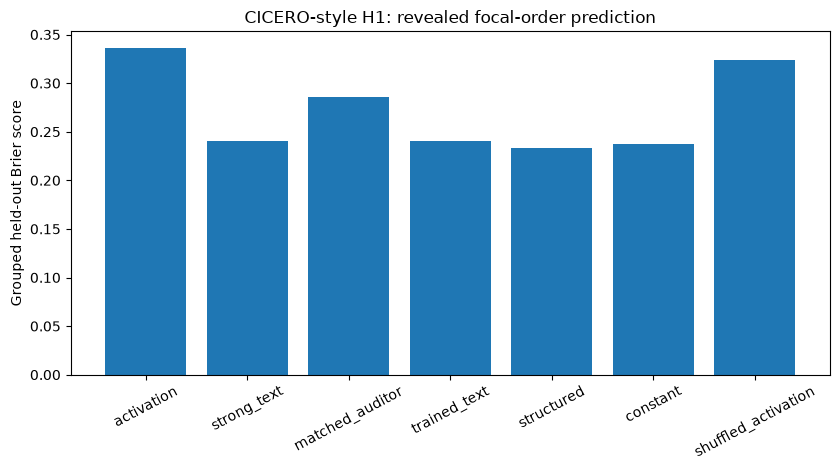

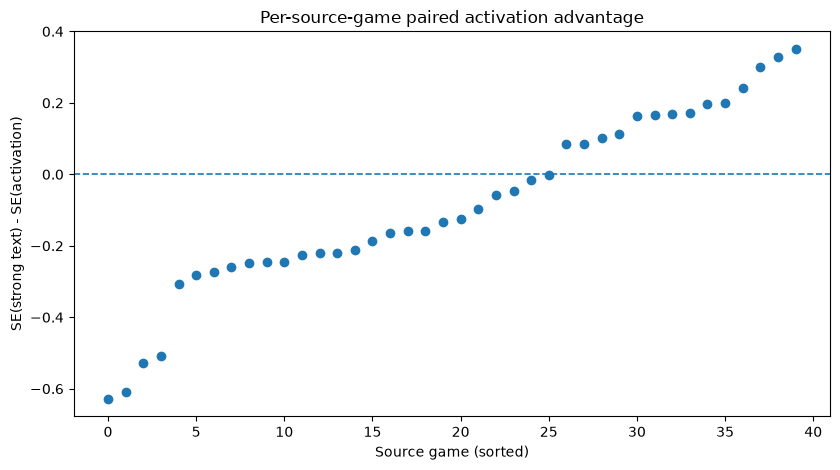

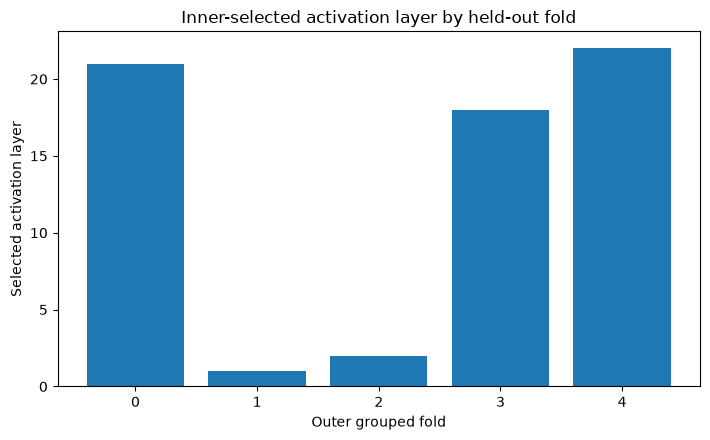

  power  states   B_rate  activation_brier  strong_text_brier
AUSTRIA       7 0.428571          0.188342           0.278837
ENGLAND      18 0.666667          0.335411           0.228636
 FRANCE      10 0.700000          0.307282           0.225031
GERMANY       6 0.666667          0.429999           0.238449
  ITALY      15 0.600000          0.368823           0.241919
 RUSSIA      16 0.625000          0.396262           0.236908
 TURKEY       4 0.500000          0.172982           0.281291


In [19]:
import matplotlib.pyplot as plt

# Brier comparison
fig, ax = plt.subplots(figsize=(8.5, 4.8))
plot_methods = ["activation", "strong_text", "matched_auditor", "trained_text", "structured", "constant", "shuffled_activation"]
ax.bar(plot_methods, [metrics[m]["brier"] for m in plot_methods])
ax.set_ylabel("Grouped held-out Brier score")
ax.set_title("CICERO-style H1: revealed focal-order prediction")
ax.tick_params(axis="x", rotation=28)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "h1_brier_methods.png", dpi=180)
plt.show()

# Source-game paired deltas
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ordered = game_delta.sort_values("delta_latent").reset_index(drop=True)
ax.scatter(np.arange(len(ordered)), ordered["delta_latent"].to_numpy())
ax.axhline(0.0, linestyle="--", linewidth=1.2)
ax.set_xlabel("Source game (sorted)")
ax.set_ylabel("SE(strong text) - SE(activation)")
ax.set_title("Per-source-game paired activation advantage")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "h1_source_game_deltas.png", dpi=180)
plt.show()

# Layer selections
fig, ax = plt.subplots(figsize=(7.2, 4.5))
ax.bar(activation_fold_df["outer_fold"].astype(str), activation_fold_df["selected_layer"])
ax.set_xlabel("Outer grouped fold")
ax.set_ylabel("Selected activation layer")
ax.set_title("Inner-selected activation layer by held-out fold")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "h1_selected_layers.png", dpi=180)
plt.show()

by_power = pred_df.groupby("power", as_index=False).agg(
    states=("state_id", "size"),
    B_rate=("y_B", "mean"),
    activation_brier=("se_activation", "mean"),
    strong_text_brier=("se_strong_text", "mean"),
)
by_power.to_csv(TABLE_DIR / "h1_by_power.csv", index=False)
print(by_power.to_string(index=False))


## 15. Final scientific decision, freeze manifest, and archive

`experiment_valid_for_h1_inference` and `h1_supported` are deliberately separate fields. A valid negative/null result is frozen exactly as a valid positive result would be.


In [ ]:
# Produce a deterministic parser-audit sample with raw outputs for human inspection before manuscript submission.
raw_records = [json.loads(line) for line in records_jsonl.read_text(encoding="utf-8").splitlines() if line.strip()]
audit_frame = pd.DataFrame([{
    "state_id": item["state_id"],
    "game_index": item["game_index"],
    "power": item["power"],
    "option_a": item["option_a"],
    "option_b": item["option_b"],
    "action_choice": item["action_choice"],
    "action_valid": item["action_valid"],
    "action_raw": item["action_raw"],
    "auditor_p_B": item["auditor_p_B"],
    "auditor_valid": item["auditor_valid"],
    "auditor_raw": item["auditor_raw"],
    "native_replay_passed": item["native_replay_passed"],
} for item in raw_records])
audit_n = min(50, len(audit_frame))
audit_sample = audit_frame.sample(n=audit_n, random_state=SEED).sort_values(["game_index", "state_id"])
audit_sample.to_csv(TABLE_DIR / "manual_parser_audit_sample.csv", index=False)

final_readiness = {
    **readiness,
    "activation_beats_shuffled_label_control": bool(activation_beats_shuffle),
    "all_heldout_predictions_complete": bool(len(pred_df) == len(valid_df)),
    "experiment_valid_for_h1_inference": bool(readiness["h1_analysis_allowed"] and len(pred_df) == len(valid_df)),
    "h1_supported": bool(h1_supported),
    "h1_decision": h1_decision,
    "manual_parser_audit_sample_rows": int(audit_n),
    "manual_parser_audit_required_before_manuscript_claim": True,
}
(TABLE_DIR / "readiness.json").write_text(json.dumps(final_readiness, indent=2))

result_summary = {
    "notebook_build": NOTEBOOK_BUILD,
        "native_runtime_isolation": "Notebook14 Python3.7/Torch1.7.1 subprocess only",
    "run_id": RUN_ID,
    "environment": "CICERO-derived full-press Diplomacy",
    "subject_model": SUBJECT_MODEL,
    "subject_revision_requested": SUBJECT_REVISION,
    "subject_revision_resolved": SUBJECT_REVISION_RESOLVED,
    "cicero_commit": CICERO_COMMIT,
    "protocol": protocol,
    "readiness": final_readiness,
    "h1_result": result,
    "claim_boundary": (
        "This notebook directly tests the original activation-vs-matched-text H1 for the local Qwen subject on CICERO-derived strategic states. "
        "It does not claim to decode Meta CICERO's own hidden neural activations, and it does not convert planner-object visibility into activation evidence."
    ),
}
(TABLE_DIR / "result_summary.json").write_text(json.dumps(result_summary, indent=2))

manifest = {
    "notebook_build": NOTEBOOK_BUILD,
        "native_runtime_isolation": "Notebook14 Python3.7/Torch1.7.1 subprocess only",
    "run_id": RUN_ID,
    "run_output_dir": str(RUN_DIR),
    "source_notebook10_run": str(NB10_RUN_DIR),
    "source_notebook11_run": str(NB11_RUN_DIR),
    "protocol_freeze": str(MANIFEST_DIR / "protocol_freeze.json"),
    "state_bank": str(TABLE_DIR / "source_state_bank_preoutcome.csv"),
    "records": str(records_jsonl),
    "activations": str(ACTIVATION_DIR / "pre_action_all_layers.safetensors"),
    "heldout_predictions": str(TABLE_DIR / "heldout_h1_predictions.csv"),
    "h1_result": str(TABLE_DIR / "h1_result.json"),
    "readiness": str(TABLE_DIR / "readiness.json"),
    "result_summary": str(TABLE_DIR / "result_summary.json"),
    "figures": sorted(str(path) for path in FIGURE_DIR.glob("*.png")),
}
(MANIFEST_DIR / "notebook19_manifest.json").write_text(json.dumps(manifest, indent=2))

# Hash every artifact before archiving.
checksums = []
for path in sorted(RUN_DIR.rglob("*")):
    if path.is_file():
        h = hashlib.sha256(path.read_bytes()).hexdigest()
        checksums.append({"path": str(path.relative_to(RUN_DIR)), "bytes": path.stat().st_size, "sha256": h})
(RUN_DIR / "checksums.json").write_text(json.dumps(checksums, indent=2))

archive_path = PROJECT_ROOT / f"19_cicero_h1_activation_vs_strong_text_{RUN_ID}.zip"
with zipfile.ZipFile(archive_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for path in sorted(RUN_DIR.rglob("*")):
        if path.is_file():
            arcname = Path(NOTEBOOK_SLUG) / RUN_ID / path.relative_to(RUN_DIR)
            zf.write(path, arcname=str(arcname))
    latest = BASE / "latest_run.json"
    if latest.exists():
        zf.write(latest, arcname=str(Path(NOTEBOOK_SLUG) / "latest_run.json"))

print(json.dumps(result_summary, indent=2))
print()
print("Notebook 19 complete.")
print("Experiment valid for H1 inference:", final_readiness["experiment_valid_for_h1_inference"])
print("H1 supported:", h1_supported)
print("Decision:", h1_decision)
print("Delta_latent:", primary_delta)
print("95% source-game bootstrap CI:", [bootstrap["ci95_low"], bootstrap["ci95_high"]])
print("Result summary:", TABLE_DIR / "result_summary.json")
print("Run directory:", RUN_DIR)
print("Archive:", archive_path)

try:
    del model
    torch.cuda.empty_cache()
except Exception:
    pass
